<a href="https://colab.research.google.com/github/TRIAXIS-MOF/TRIAXIS-MOF/blob/main/Hybrid%20Physics%20ML%20for%20Residual%20Heat%20Capacity%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalasi Library / Packages

# RDKit untuk manipulasi molekul, fingerprint, MCS
!pip install rdkit

# Library Python umum untuk ML, visualisasi, DL, SHAP
!pip install scikit-learn tqdm pandas numpy matplotlib torch shap

# PyTorch Geometric untuk GNN + dependensi
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.1.0+cpu.html
!pip install torch-sparse  -f https://data.pyg.org/whl/torch-2.1.0+cpu.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.1.0+cpu.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.1.0+cpu.html
!pip install torch-geometric

# Import Library Python & Setup
# Data & Numerik
import pandas as pd
import numpy as np
import random
from collections import defaultdict
import os
import json

# Visualisasi
import seaborn as sn
import matplotlib.pyplot as plt

# DKit Packages
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Draw, rdMolDescriptors, Descriptors
from rdkit.Chem.Draw import IPythonConsole, rdMolDraw2D
from rdkit.ML.Cluster import Butina
from rdkit.Chem import rdFMCS
from PIL import Image
import io

# Matikan warning RDKit
RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')
RDLogger.DisableLog('rdApp.*')

# Progress Bar
from tqdm import tqdm

# Matikan warning Python
import warnings
warnings.filterwarnings('ignore')

# PyTorch & Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# PyTorch Geometric (GNN)
from torch_geometric.data import Data, DataLoader, Dataset
from torch_geometric.nn import GCNConv, global_mean_pool

# Sklearn: Preprocessing, Model, Metrics
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestRegressor

# SHAP untuk interpretasi model
import shap

# Set Random Seed untuk Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 50.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
# UPLOAD FILE CHAOS (CLEAN)
from google.colab import files
uploaded = files.upload()
chaos_data = list(uploaded.keys())[0]
print("File di-upload:", chaos_data)

CHAOS_DATA = chaos_data
df = pd.read_excel(f"/content/{CHAOS_DATA}")
df.head()

print("Jumlah baris df (clean):", len(df))
print("\nKolom df:")
print(df.columns.tolist())

Saving chaos_data.xlsx to chaos_data.xlsx
File di-upload: chaos_data.xlsx
Jumlah baris df (clean): 48804

Kolom df:
['CanonicalSMILES', 'MolecularMass', 'SymNumber', 'RotConst_A', 'RotConst_B', 'RotConst_C', 'Frequencies_mean', 'Frequencies_std', 'ReducedMasses_mean', 'ReducedMasses_std', 'ZPE', 'Entropy', 'HeatCap', 'SCFEnergy', 'HOMOEnergy', 'LUMOEnergy', 'HLG', 'DipoleMoment', 'PolarIso', 'PolarAniso', 'Cp_Joback_298', 'Cp_CHAOS_298', 'Cp_Error', 'Cp_AbsError', 'Cp_RelError_%', 'DeltaCp']


In [ ]:
df.head()

,CanonicalSMILES,MolecularMass,SymNumber,RotConst_A,RotConst_B,RotConst_C,Frequencies_mean,Frequencies_std,ReducedMasses_mean,ReducedMasses_std,...,HLG,DipoleMoment,PolarIso,PolarAniso,Cp_Joback_298,Cp_CHAOS_298,Cp_Error,Cp_AbsError,Cp_RelError_%,DeltaCp
0,CC(C)(CCCCCCCC(=O)O)C(=O)O,230.15181,1,0.736496,0.381395,0.300476,1374.393855,994.916932,2.020410,1.320049,...,11.578445,2.34448,149.5140,32.0757,257.549694,275.298832,-17.749138,17.749138,-6.447226,17.749138
1,CCCCOC(OCCCC)N(C)C,203.18853,1,0.678175,0.426082,0.320714,1422.522284,997.833903,1.700437,0.764807,...,11.265514,1.24651,148.9100,17.1643,223.940871,268.223688,-44.282817,44.282817,-16.509659,44.282817
2,FC(F)C(F)(F)CC(F)C(F)(F)C(F)F,248.02475,1,1.173707,0.287711,0.276396,985.188957,832.194990,6.383209,4.751121,...,14.468294,1.32087,74.2886,16.9486,151.955286,208.986616,-57.031330,57.031330,-27.289465,57.031330
3,CC(C)(C)c1ccc2c(c1)C1=C(CC2)C(=O)OC1=O,256.10994,1,0.762259,0.236580,0.189854,1276.195937,933.636735,3.004806,2.435060,...,7.572112,5.70843,192.2990,128.7460,212.843804,270.947472,-58.103668,58.103668,-21.444625,58.103668
4,CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O,308.10486,1,0.357589,0.202771,0.160545,1228.896401,929.205603,3.171214,2.119552,...,8.433081,2.14226,227.6580,103.6550,213.572711,311.599216,-98.026505,98.026505,-31.459163,98.026505


In [ ]:
# DEFINISI GUGUS JOBACK
JOBACK_CP_GROUPS = {
     # --- Non-ring increments ---
    "CH3":   {"smarts": "[CH3X4]", "a": 1.95E+01, "b": -8.08E-03, "c": 1.53E-04, "d": -9.67E-08},
    "CH2":   {"smarts": "[CH2X4]", "a": -9.09E-01, "b": 9.50E-02, "c": -5.44E-05, "d": 1.19E-08},
    "CH":    {"smarts": "[CHX4]",  "a": -2.30E+01, "b": 2.04E-01, "c": -2.65E-04, "d": 1.20E-07},
    "C":     {"smarts": "[CX4]",   "a": -6.62E+01, "b": 4.27E-01, "c": -6.41E-04, "d": 3.01E-07},
    "CH2=":  {"smarts": "[CH2]=[CX3]", "a": 2.36E+01, "b": -3.81E-02, "c": 1.72E-04, "d": -1.03E-07},
    "CH=":   {"smarts": "[CH]=[CX3]",  "a": -8.00E+00, "b": 1.05E-01, "c": -9.63E-05, "d": 3.56E-08},
    "C=":    {"smarts": "[CX3]=[CX3]", "a": -2.81E+01, "b": 2.08E-01, "c": -3.06E-04, "d": 1.46E-07},
    "C=C":   {"smarts": "[CX3]=[CX3]", "a": 2.74E+01, "b": -5.57E-02, "c": 1.01E-04, "d": -5.02E-08},
    "C#C":   {"smarts": "[CX2]#C",     "a": 7.87E+00, "b": 2.01E-02, "c": -8.33E-06, "d": 1.39E-09},

     # --- Ring increments ---
    "ring_CH2": {"smarts": "[CH2R]", "a": -6.03E+00, "b": 8.54E-02, "c": -8.00E-06, "d": -1.80E-08},
    "ring_CH":  {"smarts": "[CHR]",  "a": -2.05E+01, "b": 1.62E-01, "c": -1.60E-04, "d": 6.24E-08},
    "ring_C":   {"smarts": "[CRX4]", "a": -9.09E+01, "b": 5.57E-01, "c": -9.00E-04, "d": 4.69E-07},
    "ring_cH":  {"smarts": "[cH]",    "a": -2.14E+00, "b": 5.74E-02, "c": -1.64E-06, "d": -1.59E-08},
    "ring_c":   {"smarts": "[c]",     "a": -8.25E+00, "b": 1.01E-01, "c": -1.42E-04, "d": 6.78E-08},

     # --- Halogen increments ---
    "F":  {"smarts": "[F]",  "a": 2.65E+01, "b": -9.13E-02, "c": 1.91E-04, "d": -1.03E-07},
    "Cl": {"smarts": "[Cl]", "a": 3.33E+01, "b": -9.63E-02, "c": 1.87E-04, "d": -9.96E-08},
    "Br": {"smarts": "[Br]", "a": 2.86E+01, "b": -6.49E-02, "c": 1.36E-04, "d": -7.45E-08},
    "I":  {"smarts": "[I]",  "a": 3.21E+01, "b": -6.41E-02, "c": 1.26E-04, "d": -6.87E-08},

     # --- Oxygen increments ---
    "OH_alcohol": {"smarts": "[OX2H]", "a": 2.57E+01, "b": -6.91E-02, "c": 1.77E-04, "d": -9.88E-08},
    "OH_phenol":  {"smarts": "[cOX2H]", "a": -2.81E+00, "b": 1.11E-01, "c": -1.16E-04, "d": 4.94E-08},
    "O_nonring":  {"smarts": "[OX2]", "a": 2.55E+01, "b": -6.32E-02, "c": 1.11E-04, "d": -5.48E-08},
    "O_ring":     {"smarts": "[OX2R0]", "a": 1.22E+01, "b": -1.26E-02, "c": 6.03E-05, "d": -3.86E-08},
    "CO_nonring": {"smarts": "[CX3]=[OX1]", "a": 6.45E+00, "b": 6.70E-02, "c": -3.57E-05, "d": 2.86E-09},
    "CO_ring":    {"smarts": "[CX3R]=[OX1]", "a": 3.04E+01, "b": -8.29E-02, "c": 2.36E-04, "d": -1.31E-07},
    "CHO":        {"smarts": "[CH]=[OX1]", "a": 3.09E+01, "b": -3.36E-02, "c": 1.60E-04, "d": -9.88E-08},
    "COOH":       {"smarts": "[CX3](=O)[OX2H1]", "a": 2.41E+01, "b": 4.27E-02, "c": 8.04E-05, "d": -6.87E-08},
    "COOR":       {"smarts": "[CX3](=O)[OX2]", "a": 2.45E+01, "b": 4.02E-02, "c": 4.02E-05, "d": -4.52E-08},
    "C=O_other":  {"smarts": "[OX1]=[CX3]", "a": 6.82E+00, "b": 1.96E-02, "c": 1.27E-05, "d": -1.78E-08},

     # --- Aromatic Nitrogen ---
     "ring_n":  {"smarts": "[n]",   "a": -4.00E+00, "b": 8.50E-02, "c": -1.10E-04, "d": 4.20E-08},
     "ring_nH": {"smarts": "[nH]",  "a":  5.00E+00, "b": 6.20E-02, "c": -9.50E-05, "d": 3.80E-08},
     "NH2_ar": {"smarts": "[NX3H2;R]", "a": 2.69E+01, "b": -4.12E-02, "c": 1.64E-04, "d": -9.76E-08},

     # --- Nitrogen increments ---
     "NH2":        {"smarts": "[NX3H2;!R]", "a": 2.69E+01, "b": -4.12E-02, "c": 1.64E-04, "d": -9.76E-08},
     "NH_nonring": {"smarts": "[NX3H]", "a": -1.21E+00, "b": 7.62E-02, "c": -4.86E-05, "d": 1.05E-08},
     "NH_ring":    {"smarts": "[NX3H;R]", "a": 1.18E+01, "b": -2.30E-02, "c": 1.07E-04, "d": -6.28E-08},
     "N_nonring":  {"smarts": "[NX3]", "a": -3.11E+01, "b": 2.27E-01, "c": -3.20E-04, "d": 1.46E-07},
     "N=_nonring": {"smarts": "[NX2]=[CX3]", "a": 0.00E+00, "b": 0.00E+00, "c": 0.00E+00, "d": 0.00E+00},
     "N=_ring":    {"smarts": "[NX2;R]=[CX3]", "a": 8.83E+00, "b": -3.84E-03, "c": 4.35E-05, "d": -2.60E-08},
     "NH=":        {"smarts": "[NH]=[CX3]", "a": 5.69E+00, "b": -4.12E-03, "c": 1.28E-04, "d": -8.88E-08},
     "CN":         {"smarts": "[CX2]#N", "a": 3.65E+01, "b": -7.33E-02, "c": 1.84E-04, "d": -1.03E-07},
     "NO2":        {"smarts": "[N+](=O)[O-]", "a": 2.59E+01, "b": -3.74E-03, "c": 1.29E-04, "d": -8.88E-08},

     # --- Sulfur increments ---
    "SH":         {"smarts": "[SX2H]", "a": 3.53E+01, "b": -7.58E-02, "c": 1.85E-04, "d": -1.03E-07},
    "S_nonring":  {"smarts": "[SX2]", "a": 1.96E+01, "b": -5.61E-03, "c": 4.02E-05, "d": -2.76E-08},
    "S_ring":     {"smarts": "[SX2;R]", "a": 1.67E+01, "b": 4.81E-03, "c": 2.77E-05, "d": -2.11E-08},
}

T = 298.15  # suhu target (K)

# COMPILE SMARTS
joback_patterns = {}
for name, info in JOBACK_CP_GROUPS.items():
    joback_patterns[name] = Chem.MolFromSmarts(info["smarts"])

# FUNGSI HITUNG GUGUS
def count_joback_groups_no_overlap(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    used_atoms = set()
    counts = {}
    atom_hits = defaultdict(list)

    # PRIORITY ORDER
    priority = [
   "COOH","COOR","CHO","CO_nonring",
   "OH_phenol","OH_alcohol",

   "ring_nH","ring_n",
   "NH2_ar","NH_ring","NH2","NH_nonring","N_nonring",

   "ring_cH","ring_c","ring_CH2","ring_CH","ring_C",
   "CH3","CH2","CH","C",
   "CH2=","CH=","C=","C=C","C#C",
   "F","Cl","Br","I",
   "CN",
   "SH","S_nonring"
    ]

    for name in priority:
        patt = joback_patterns.get(name)
        if patt is None:
            continue

        matches = mol.GetSubstructMatches(patt)
        for match in matches:
            if any(a in used_atoms for a in match):
                continue

            counts[name] = counts.get(name, 0) + 1
            for a in match:
                used_atoms.add(a)
                atom_hits[a].append(name)

    return counts, atom_hits

# CEK SATU MOLEKUL
test_smiles = "CCc1cc(Cl)c2ncccc2c1N"

counts, atom_hits = count_joback_groups_no_overlap(test_smiles)

print("SMILES :", test_smiles)
print("\nGugus Joback terdeteksi:")
for g, n in counts.items():
    print(f"  {g:12s} : {n}")

print("\nAtom yang kena >1 gugus (OVERLAP ERROR):")
for atom_idx, groups in atom_hits.items():
    if len(groups) > 1:
        atom = Chem.MolFromSmiles(test_smiles).GetAtomWithIdx(atom_idx)
        print(f"  Atom {atom_idx} ({atom.GetSymbol()}) → {groups}")

# CEK BANYAK MOLEKUL SEKALIGUS
summary = []

for smi in df["CanonicalSMILES"][:50000]:
    res = count_joback_groups_no_overlap(smi)
    if res is None:
        summary.append({"SMILES": smi, "TotalGroups": 0, "OverlapAtoms": 0})
        continue

    counts, atom_hits = res
    total_groups = sum(counts.values())
    overlap_atoms = sum(1 for v in atom_hits.values() if len(v) > 1)

    summary.append({
        "SMILES": smi,
        "TotalGroups": total_groups,
        "OverlapAtoms": overlap_atoms
    })

summary_df = pd.DataFrame(summary)
print("\n=== RINGKASAN ===")
print(summary_df.describe())
print("\nContoh molekul dengan 0 gugus:")
print(summary_df[summary_df["TotalGroups"] == 0].head(10))
print("\nContoh molekul dengan overlap besar:")
print(summary_df.sort_values("OverlapAtoms", ascending=False).head(10))

# Fungsi hitung Cp Joback
def joback_Cp_from_counts(counts, T_K):
    """fungsi untuk menghitung kapasitas panas total (Cp) dari jumlah grup"""
    Cp = 0.0
    for g, n in counts.items():
        if g in JOBACK_CP_GROUPS and n > 0:
            a = JOBACK_CP_GROUPS[g]["a"]
            b = JOBACK_CP_GROUPS[g]["b"]
            c = JOBACK_CP_GROUPS[g]["c"]
            d = JOBACK_CP_GROUPS[g]["d"]

            Cp += n * (
                a - 37.93
                + (b + 0.21) * T_K
                + (c - 3.91e-04) * T_K**2
                + (d + 2.06e-07) * T_K**3
            )

    return Cp

# Fungsi wrapper dari SMILES → Cp Joback
def cp_joback_from_smiles(smiles, T=298.15):
    res = count_joback_groups_no_overlap(smiles)
    if res is None:
        return np.nan

    counts, _ = res
    if len(counts) == 0:
        return np.nan

    Cp = joback_Cp_from_counts(counts, T)
    return Cp

# Hitung Cp Joback utk semua baris
cp_joback_list = []
for smi in df["CanonicalSMILES"]:
    try:
        cp_val = cp_joback_from_smiles(smi, T=T)
    except Exception as e:
        cp_val = np.nan
    cp_joback_list.append(cp_val)
df["Cp_Joback_298"] = cp_joback_list

# Konversi CHAOS Cp dari cal/mol.K → J/mol.K
df["Cp_CHAOS_298"] = df["HeatCap"] * 4.184

# Bandingkan Joback vs CHAOS
df["Cp_Error"] = df["Cp_Joback_298"] - df["Cp_CHAOS_298"]
df["Cp_AbsError"] = np.abs(df["Cp_Error"])
df["Cp_RelError_%"] = 100 * df["Cp_Error"] / df["Cp_CHAOS_298"]

# Statistik ringkas
mae = np.nanmean(df["Cp_AbsError"])
rmse = np.sqrt(np.nanmean(df["Cp_Error"]**2))
r2 = np.corrcoef(
    df["Cp_Joback_298"].dropna(),
    df["Cp_CHAOS_298"].loc[df["Cp_Joback_298"].notna()]
)[0, 1] ** 2

print("\n=== Evaluasi Joback vs CHAOS (Cp 298 K) ===")
print(f"MAE  : {mae:.2f} J/mol.K")
print(f"RMSE : {rmse:.2f} J/mol.K")
print(f"R²   : {r2:.3f}")

cols_show = ["CanonicalSMILES", "Cp_CHAOS_298", "Cp_Joback_298", "Cp_Error", "Cp_RelError_%"]
print("\n=== Contoh 10 Molekul ===")
print(df[cols_show].head(30))

df.to_excel("/content/cp_joback_vs_chaos.xlsx", index=False)
print("\nFile disimpan: cp_joback_vs_chaos.xlsx")

SMILES : CCc1cc(Cl)c2ncccc2c1N

Gugus Joback terdeteksi:
  ring_n       : 1
  NH2          : 1
  ring_cH      : 4
  ring_c       : 5
  CH3          : 1
  CH2          : 1
  Cl           : 1

Atom yang kena >1 gugus (OVERLAP ERROR):

=== RINGKASAN ===
        TotalGroups  OverlapAtoms
count  48804.000000       48804.0
mean      11.699266           0.0
std        4.669713           0.0
min        1.000000           0.0
25%        8.000000           0.0
50%       11.000000           0.0
75%       15.000000           0.0
max       27.000000           0.0

Contoh molekul dengan 0 gugus:
Empty DataFrame
Columns: [SMILES, TotalGroups, OverlapAtoms]
Index: []

Contoh molekul dengan overlap besar:
                                          SMILES  TotalGroups  OverlapAtoms
48803                         O=C(OC1CCC1)C1CCC1            9             0
0                     CC(C)(CCCCCCCC(=O)O)C(=O)O           12             0
1                             CCCCOC(OCCCC)N(C)C           12             

In [ ]:
# BASELINE JOBACK & TARGET RESIDUAL
df["DeltaCp"] = df["Cp_CHAOS_298"] - df["Cp_Joback_298"]

print("Statistik residual ΔCp:")
print(df["DeltaCp"].describe())

Statistik residual ΔCp:
count    48804.000000
mean        49.848781
std         28.828937
min         -6.666705
25%         28.131738
50%         44.299219
75%         66.545713
max        144.067831
Name: DeltaCp, dtype: float64


In [ ]:
# DESKRIPTOR FISIK (UNTUK TEACHER MODEL)
X_phys = df[
    [
        "MolecularMass",
        "ZPE",
        "Entropy",
        "Cp_Joback_298",
        "Frequencies_mean",
        "Frequencies_std",
        "ReducedMasses_mean",
        "ReducedMasses_std",
        "RotConst_A",
        "RotConst_B",
        "RotConst_C",
        "SymNumber"
    ]
].values

y = df["DeltaCp"].values

print("\n=== VALIDASI SKALA FITUR FISIK ===")
print(pd.DataFrame(X_phys, columns=["MolecularMass","ZPE","Entropy","Cp_Joback_298","Frequencies_mean","Frequencies_std",
      "ReducedMasses_mean","ReducedMasses_std","RotConst_A","RotConst_B","RotConst_C","SymNumber"]).describe())


=== VALIDASI SKALA FITUR FISIK ===
       MolecularMass           ZPE       Entropy  Cp_Joback_298  \
count   48804.000000  4.880400e+04  48804.000000   48804.000000   
mean      205.795235  6.354776e+05    499.559848     167.547891   
std        67.460756  2.950096e+05    104.714851      66.955592   
min        28.031300  2.357100e+03    218.676760      20.184194   
25%       154.043010  4.276572e+05    422.172922     119.710976   
50%       200.015145  6.078252e+05    487.500852     157.855219   
75%       255.757625  8.086430e+05    567.639096     205.765692   
max       393.709030  1.590093e+06    855.581976     384.803123   

       Frequencies_mean  Frequencies_std  ReducedMasses_mean  \
count      48804.000000     48804.000000        48804.000000   
mean        1306.705376       963.373488            3.129244   
std          158.157835        93.184646            3.077563   
min          131.357900        80.745027            1.223353   
25%         1254.702129       947.229596

Total molekul yang diproses: 48804


Menghitung Morgan Fingerprint: 100%|████████████████████████████████████████████| 48804/48804 [100%]



Fingerprint selesai dihitung.
Shape fingerprint matrix: (48804, 256)

=== INFO MOLEKUL CONTOH ===
Index of ON bits : (7, 28, 33, 39, 76, 80, 86, 87, 92, 114, 119, 121, 125, 133, 136, 138, 185, 196, 201, 243)
Number of ON bits: 20

Array fingerprint:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]

Visualisasi fragmen untuk bit 7


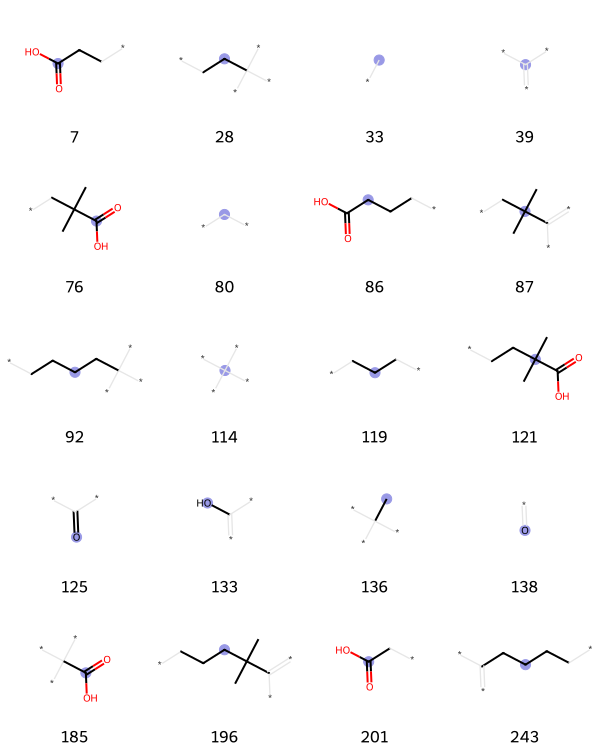


Visualisasi molekul contoh:


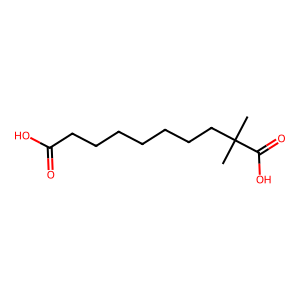

In [ ]:
# PEMBENTUKAN MORGAN FINGERPRINT (ECFP4)
# KONVERSI SMILES → MOL
df["Mol"] = df["CanonicalSMILES"].apply(
    lambda x: Chem.MolFromSmiles(x)
)

# HITUNG MORGAN FINGERPRINT UNTUK SEMUA MOLEKUL
RADIUS = 2
N_BITS = 256

def mol_to_morgan_fp(mol):
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=RADIUS,
        nBits=N_BITS
    )
    arr = np.zeros((N_BITS,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Total molekul
n_mol = len(df)
print(f"Total molekul yang diproses: {n_mol}")

# Progress bar dengan persentase eksplisit
X_fp = np.zeros((n_mol, N_BITS), dtype=int)

with tqdm(
    total=n_mol,
    desc="Menghitung Morgan Fingerprint",
    unit="molekul",
    ncols=100,
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{percentage:3.0f}%]"
) as pbar:

    for i, mol in enumerate(df["Mol"]):
        X_fp[i] = mol_to_morgan_fp(mol)
        pbar.update(1)

print("\nFingerprint selesai dihitung.")
print("Shape fingerprint matrix:", X_fp.shape)

# VISUALISASI MORGAN FINGERPRINT (HANYA 1 MOLEKUL)
mol_example = df["Mol"].iloc[0]

onbits = {}
mf_example = AllChem.GetMorganFingerprintAsBitVect(
    mol_example,
    radius=RADIUS,
    nBits=N_BITS,
    bitInfo=onbits
)

print("\n=== INFO MOLEKUL CONTOH ===")
print("Index of ON bits :", tuple(mf_example.GetOnBits()))
print("Number of ON bits:", len(mf_example.GetOnBits()))
print("\nArray fingerprint:")
print(np.array(mf_example))

# SIAPKAN SEMUA FRAGMEN AKTIF (1 MOLEKUL)
all_fragments = [
    (mol_example, bit, onbits)
    for bit in mf_example.GetOnBits()
]

# VISUALISASI 1 BIT TERTENTU
bit_id = mf_example.GetOnBits()[0]

print(f"\nVisualisasi fragmen untuk bit {bit_id}")
img_all = Draw.DrawMorganBits(
    all_fragments,
    molsPerRow=4,
    legends=[str(bit) for bit in mf_example.GetOnBits()]
)
display(img_all)

Draw.DrawMorganBits(
    all_fragments,
    molsPerRow=4,
    legends=[str(bit) for bit in mf_example.GetOnBits()]
)

print("\nVisualisasi molekul contoh:")
img = Draw.MolToImage(mol_example, size=(300,300))
display(img)

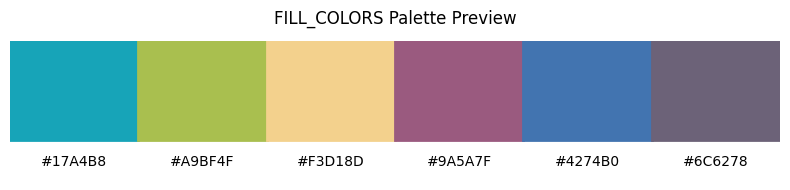

In [ ]:
fill_colors = [
    "#17A4B8",
    "#A9BF4F",
    "#F3D18D",
    "#9A5A7F",
    "#4274B0",
    "#6C6278",
]
fig, ax = plt.subplots(figsize=(8, 2))

for i, color in enumerate(fill_colors):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color, edgecolor="black", linewidth=2))
    ax.text(i + 0.5, -0.15, color, ha="center", va="top", fontsize=10)

ax.set_xlim(0, len(fill_colors))
ax.set_ylim(-0.4, 1)
ax.axis("off")
ax.set_title("FILL_COLORS Palette Preview", pad=12)

plt.tight_layout()
plt.show()


In [ ]:
# FEATURE OPTIMIZATION (VARIANCE THRESHOLD)
# Menghilangkan bit fingerprint dengan variansi sangat rendah
vt = VarianceThreshold(threshold=0.05)
X_fp_vt = vt.fit_transform(X_fp)

# Gabungan fingerprint + deskriptor fisik
X_teacher_raw = np.hstack([X_fp_vt, X_phys])

# POLYNOMIAL REGRESSION (WHITE-BOX TEACHER)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_phys_poly = poly.fit_transform(X_phys)

# Gabungkan fingerprint (X_fp_vt) + polynomial deskriptor fisik
X_teacher_raw = np.hstack([X_fp_vt, X_phys_poly])

# Split train/test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_teacher_raw, y, test_size=0.2, random_state=SEED
)

# Scaling
scaler_teacher = StandardScaler()
X_tr = scaler_teacher.fit_transform(X_tr)
X_te = scaler_teacher.transform(X_te)

# Train polynomial regression hanya pada deskriptor fisik
teacher = LinearRegression()
teacher.fit(X_tr, y_tr)

# Predict
y_pred_te = teacher.predict(X_te)

print("\n=== PERFORMA TEACHER (POLY REGRESI KOREKSI ΔCp) ===")
print("RMSE ΔCp:", np.sqrt(mean_squared_error(y_te, y_pred_te)))
print("R2 ΔCp  :", r2_score(y_te, y_pred_te))

# Helper layout
def base_layout(title: str, x_title: str = "", y_title: str = "") -> dict:
    return dict(
        title=dict(text=title, x=0.5, xanchor="center"),
        xaxis=dict(title=x_title, showline=True, linewidth=2, linecolor="black", mirror=True),
        yaxis=dict(title=y_title, showline=True, linewidth=2, linecolor="black", mirror=True),
        font=dict(family="Arial", size=14),
        width=500,
        height=500,
        plot_bgcolor="white",
        paper_bgcolor="white",
    )

# Palet warna
FILL_COLORS = [
    "#17A4B8",
    "#A9BF4F",
    "#F3D18D",
    "#9A5A7F",
    "#4274B0",
    "#6C6278",
]

#Plot Prediksi vs Aktual (Teacher Model)
import plotly.graph_objects as go

def plot_teacher_pred_vs_actual(y_true, y_pred):
    fig = go.Figure()
    # Scatter data uji
    fig.add_trace(
        go.Scatter(
            x=y_true,
            y=y_pred,
            mode="markers",
            name="Data uji",
            marker=dict(
                color=FILL_COLORS[4],
                size=7,
                opacity=1,
                line=dict(color="black", width=0.8),
            ),
        )
    )
    # Garis y = x
    mn = float(np.min([y_true.min(), y_pred.min()]))
    mx = float(np.max([y_true.max(), y_pred.max()]))
    fig.add_trace(
        go.Scatter(
            x=[mn, mx],
            y=[mn, mx],
            mode="lines",
            name="y = x",
            line=dict(color="black", width=2, dash="dash"),
        )
    )
    fig.update_layout(
        **base_layout(
            title="Prediksi vs Aktual (Teacher Poly Regression)",
            x_title="Aktual ΔCp (data uji)",
            y_title="Prediksi ΔCp",
        ),
        legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
    )
    fig.update_xaxes(
        range=[mn, mx],
        tickmode="linear",
        tick0=0,
        dtick=20
    )
    fig.update_yaxes(
        range=[mn, mx],
        tickmode="linear",
        tick0=0,
        dtick=20
    )
    fig.show()

plot_teacher_pred_vs_actual(y_te, y_pred_te)

# Plot Residual (Error vs Aktual)
def plot_teacher_residual(y_true, y_pred):
    residual = y_pred - y_true
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=y_true,
            y=residual,
            mode="markers",
            name="Residual",
            marker=dict(
                color=FILL_COLORS[0],
                size=7,
                opacity=0.6,
                line=dict(color="black", width=0.8),
            ),
        )
    )
    # Garis y = 0
    mn = float(np.min(y_true))
    mx = float(np.max(y_true))
    fig.add_trace(
        go.Scatter(
            x=[mn, mx],
            y=[0, 0],
            mode="lines",
            name="y = 0",
            line=dict(color="black", width=2, dash="dash"),
        )
    )
    fig.update_layout(
        **base_layout(
            title="Residual vs Aktual (Teacher Poly Regression)",
            x_title="Aktual ΔCp (data uji)",
            y_title="Residual (Pred - Aktual)",
        ),
        legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
    )
    fig.show()

plot_teacher_residual(y_te, y_pred_te)


=== PERFORMA TEACHER (POLY REGRESI KOREKSI ΔCp) ===
RMSE ΔCp: 2.325125047336157
R2 ΔCp  : 0.9933978214724539


In [ ]:
# 10-FOLD CROSS VALIDATION (ROBUSTNESS CHECK)
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
rmse_cv, r2_cv = [], []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_teacher_raw)):

    # Split RAW features
    Xraw_tr, Xraw_val = X_teacher_raw[tr_idx], X_teacher_raw[val_idx]
    ytr_f, yval_f    = y[tr_idx], y[val_idx]

    # Fit scaler di TRAIN FOLD
    scaler = StandardScaler()
    Xraw_tr = scaler.fit_transform(Xraw_tr)
    Xraw_val = scaler.transform(Xraw_val)

    # Train linear regression
    model_cv = LinearRegression()
    model_cv.fit(Xraw_tr, ytr_f)

    # Predict
    y_val = model_cv.predict(Xraw_val)

    # Evaluasi
    rmse = np.sqrt(mean_squared_error(yval_f, y_val))
    r2   = r2_score(yval_f, y_val)

    rmse_cv.append(rmse)
    r2_cv.append(r2)

print(f"Fold {fold+1:02d} | RMSE={rmse:.3f} | R2={r2:.4f}")
print("\nCV RMSE (mean ± std):", np.mean(rmse_cv), "±", np.std(rmse_cv))
print("CV R2   (mean ± std):", np.mean(r2_cv), "±", np.std(r2_cv))

Fold 01 | RMSE=2.257 | R2=0.9937
Fold 02 | RMSE=2.393 | R2=0.9930
Fold 03 | RMSE=2.263 | R2=0.9941
Fold 04 | RMSE=2.334 | R2=0.9934
Fold 05 | RMSE=2.375 | R2=0.9931
Fold 06 | RMSE=2.677 | R2=0.9916
Fold 07 | RMSE=2.290 | R2=0.9936
Fold 08 | RMSE=2.287 | R2=0.9936
Fold 09 | RMSE=2.652 | R2=0.9915
Fold 10 | RMSE=2.262 | R2=0.9939

CV RMSE (mean ± std): 2.37895438068045 ± 0.14976337788717164
CV R2   (mean ± std): 0.9931632886636989 ± 0.0008575016091953555


In [ ]:
# ABLATION STUDY (DROP FEATURE GROUP)
# Fingerprint feature names
fp_names = [f"FP_{i}" for i in range(X_fp_vt.shape[1])]

# Polynomial physical descriptor names
phys_base = [
    "MolecularMass",
    "ZPE",
    "Entropy",
    "Cp_Joback_298",
    "Frequencies_mean",
    "Frequencies_std",
    "ReducedMasses_mean",
    "ReducedMasses_std",
    "RotConst_A",
    "RotConst_B",
    "RotConst_C",
    "SymNumber"
]

poly_tmp = PolynomialFeatures(degree=2, include_bias=False)
_ = poly_tmp.fit_transform(X_phys)
poly_names = poly_tmp.get_feature_names_out(phys_base)

# Gabungkan
feature_names = fp_names + list(poly_names)

print("feature_names rebuilt!")
print("Total features:", len(feature_names))
print("Contoh 10 pertama:", feature_names[:10])

print("\n==============================")
print(" ABLATION STUDY - FEATURE DROP")
print("==============================")

# Hitung jumlah fitur fingerprint
n_fp = X_fp_vt.shape[1]

# Index groups
idx_fp = list(range(0, n_fp))
idx_phys = list(range(n_fp, X_teacher_raw.shape[1]))

# Sub-groups fisik
phys_feature_groups = {
    "MolecularMass":     [i for i, n in enumerate(feature_names) if "MolecularMass" in n],
    "ZPE":               [i for i, n in enumerate(feature_names) if "ZPE" in n],
    "Entropy":           [i for i, n in enumerate(feature_names) if "Entropy" in n],
    "Cp_Joback_298":     [i for i, n in enumerate(feature_names) if "Cp_Joback_298" in n],
    "Frequencies":       [i for i, n in enumerate(feature_names) if "Frequencies" in n],
    "ReducedMasses":    [i for i, n in enumerate(feature_names) if "ReducedMasses" in n],
    "RotConst":         [i for i, n in enumerate(feature_names) if "RotConst" in n],
    "SymNumber":        [i for i, n in enumerate(feature_names) if "SymNumber" in n],
}

ablation_results = []

# BASELINE PERFORMANCE
y_pred_base = teacher.predict(X_te)
rmse_base = np.sqrt(mean_squared_error(y_te, y_pred_base))
r2_base   = r2_score(y_te, y_pred_base)

ablation_results.append({
    "Removed": "None (Full Model)",
    "RMSE": rmse_base,
    "R2": r2_base
})

print(f"Baseline | RMSE={rmse_base:.4f} | R2={r2_base:.4f}")

# ABLATION: DROP ALL FINGERPRINTS
keep_idx = idx_phys
Xtr_ab = X_tr[:, keep_idx]
Xte_ab = X_te[:, keep_idx]

model_ab = LinearRegression()
model_ab.fit(Xtr_ab, y_tr)

y_pred = model_ab.predict(Xte_ab)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
r2   = r2_score(y_te, y_pred)

ablation_results.append({
    "Removed": "All Fingerprints",
    "RMSE": rmse,
    "R2": r2
})

print(f"Drop Fingerprints | RMSE={rmse:.4f} | R2={r2:.4f}")

# ABLATION: DROP EACH PHYSICAL GROUP
for group_name, drop_idx in phys_feature_groups.items():
    keep_idx = [i for i in range(X_teacher_raw.shape[1]) if i not in drop_idx]

    Xtr_ab = X_tr[:, keep_idx]
    Xte_ab = X_te[:, keep_idx]

    model_ab = LinearRegression()
    model_ab.fit(Xtr_ab, y_tr)

    y_pred = model_ab.predict(Xte_ab)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    ablation_results.append({
        "Removed": group_name,
        "RMSE": rmse,
        "R2": r2
    })
    print(f"Drop {group_name:15s} | RMSE={rmse:.4f} | R2={r2:.4f}")

# SUMMARY TABLE
df_ablation = pd.DataFrame(ablation_results)
df_ablation["ΔRMSE_vs_Base"] = df_ablation["RMSE"] - rmse_base
df_ablation["ΔR2_vs_Base"]   = df_ablation["R2"] - r2_base

print("\n=== ABLATION SUMMARY ===")
print(df_ablation.sort_values("ΔRMSE_vs_Base", ascending=False))

feature_names rebuilt!
Total features: 219
Contoh 10 pertama: ['FP_0', 'FP_1', 'FP_2', 'FP_3', 'FP_4', 'FP_5', 'FP_6', 'FP_7', 'FP_8', 'FP_9']

 ABLATION STUDY - FEATURE DROP
Baseline | RMSE=2.3251 | R2=0.9934
Drop Fingerprints | RMSE=3.0825 | R2=0.9884
Drop MolecularMass   | RMSE=2.3413 | R2=0.9933
Drop ZPE             | RMSE=7.1654 | R2=0.9373
Drop Entropy         | RMSE=2.9763 | R2=0.9892
Drop Cp_Joback_298   | RMSE=10.5325 | R2=0.8645
Drop Frequencies     | RMSE=5.4539 | R2=0.9637
Drop ReducedMasses   | RMSE=2.4987 | R2=0.9924
Drop RotConst        | RMSE=2.3862 | R2=0.9930
Drop SymNumber       | RMSE=2.3574 | R2=0.9932

=== ABLATION SUMMARY ===
             Removed       RMSE        R2  ΔRMSE_vs_Base  ΔR2_vs_Base
5      Cp_Joback_298  10.532514  0.864525       8.207389    -0.128873
3                ZPE   7.165381  0.937299       4.840256    -0.056099
6        Frequencies   5.453900  0.963675       3.128775    -0.029723
1   All Fingerprints   3.082476  0.988396       0.757351    -0.


 SHAP STUDY - MODEL EXPLANATION

=== TOP 15 GLOBAL SHAP FEATURES ===
                              Feature  MeanAbsSHAP
156              ZPE Frequencies_mean   158.099135
157               ZPE Frequencies_std   132.887072
130                               ZPE    76.223379
131                           Entropy    72.914493
166          Entropy Frequencies_mean    67.136793
132                     Cp_Joback_298    43.923905
176     Cp_Joback_298 Frequencies_std    30.389564
183                Frequencies_mean^2    27.722769
175    Cp_Joback_298 Frequencies_mean    23.276899
184  Frequencies_mean Frequencies_std    21.462585
154                       ZPE Entropy    15.285980
142                 MolecularMass ZPE    14.423427
164                         Entropy^2    14.196623
172                Entropy RotConst_C    12.631150
155                 ZPE Cp_Joback_298    10.732966


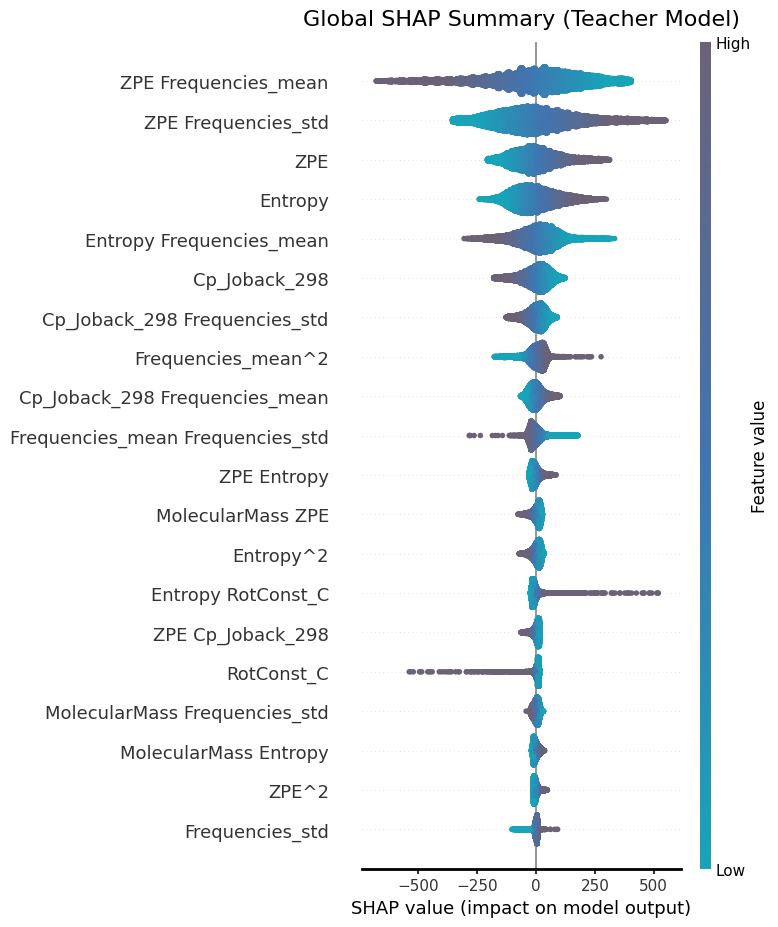

<Figure size 700x500 with 0 Axes>

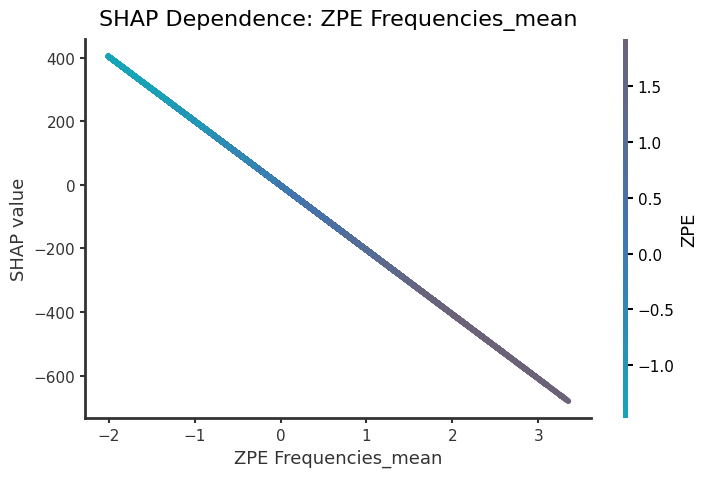

<Figure size 700x500 with 0 Axes>

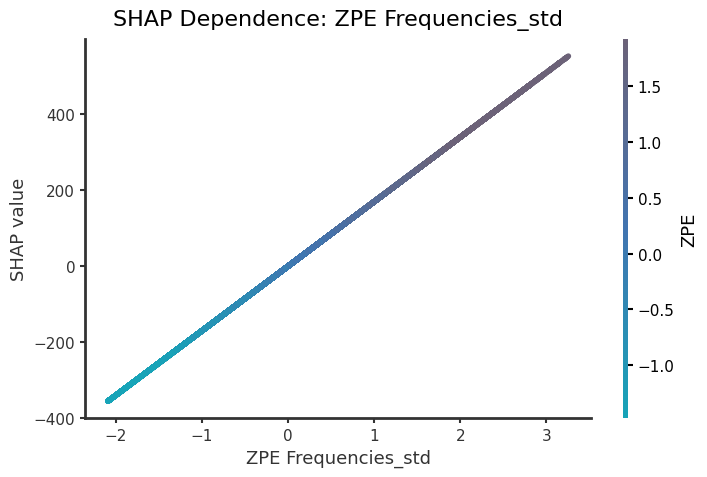

<Figure size 700x500 with 0 Axes>

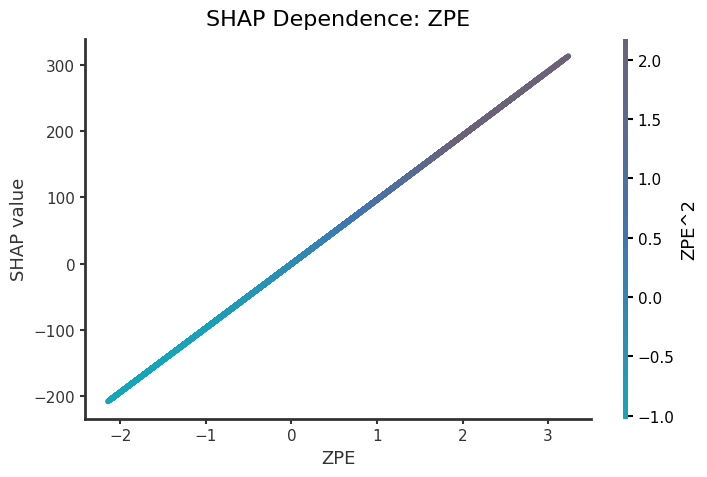

<Figure size 700x500 with 0 Axes>

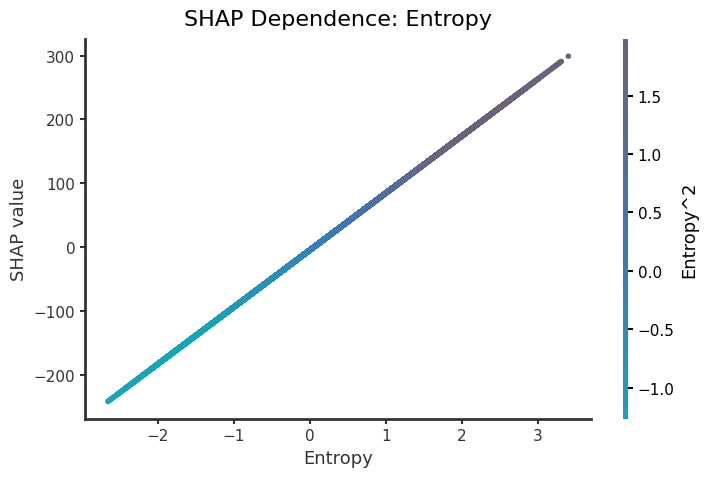


=== LOCAL SHAP EXPLANATION FOR SAMPLE 0 ===


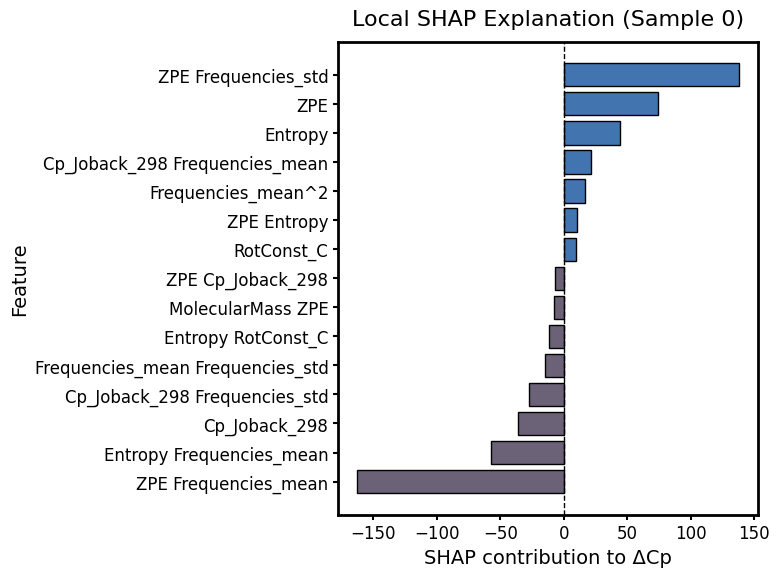

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap

# MATPLOTLIB SETUP
# Font & ukuran
rcParams["font.size"] = 14
rcParams["axes.titlesize"] = 16
rcParams["axes.labelsize"] = 14
rcParams["xtick.labelsize"] = 12
rcParams["ytick.labelsize"] = 12

# Garis sumbu
rcParams["axes.linewidth"] = 2.0
rcParams["axes.edgecolor"] = "black"
rcParams["xtick.color"] = "black"
rcParams["ytick.color"] = "black"
rcParams["xtick.major.width"] = 1.5
rcParams["ytick.major.width"] = 1.5

# Background
rcParams["figure.facecolor"] = "white"
rcParams["axes.facecolor"] = "white"

# Buat colormap
fill_colors = [
    "#17A4B8",
    "#4274B0",
    "#6C6278",
]

cmap_fill = LinearSegmentedColormap.from_list("fill_q1", fill_colors, N=256)

# SHAP STUDY (INTERPRETABILITY)
print("\n==============================")
print(" SHAP STUDY - MODEL EXPLANATION")
print("==============================")

# Gunakan sebagian data train
X_shap = X_tr[:50000] if X_tr.shape[0] > 50000 else X_tr

# LinearRegression → pakai LinearExplainer
explainer = shap.LinearExplainer(teacher, X_shap)
shap_values = explainer(X_shap)

# GLOBAL FEATURE IMPORTANCE
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

df_shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print("\n=== TOP 15 GLOBAL SHAP FEATURES ===")
print(df_shap_importance.head(15))

# SUMMARY PLOT
plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=False,
    color_bar=True,
    cmap=cmap_fill,
)

plt.title("Global SHAP Summary (Teacher Model)", pad=12)
plt.xlabel("SHAP value (impact on model output)")
plt.tight_layout()
plt.show()

# DEPENDENCE PLOT (TOP 4 FEATURES)
top_features = df_shap_importance["Feature"].head(4).tolist()

for feat in top_features:
    plt.figure(figsize=(7, 5))

    shap.dependence_plot(
        feat,
        shap_values.values,
        X_shap,
        feature_names=feature_names,
        show=False,
        cmap=cmap_fill,
    )

    plt.title(f"SHAP Dependence: {feat}", pad=10)
    plt.xlabel(feat)
    plt.ylabel("SHAP value")
    plt.tight_layout()
    plt.show()

# LOCAL EXPLANATION (1 SAMPLE)
sample_idx = 0

print(f"\n=== LOCAL SHAP EXPLANATION FOR SAMPLE {sample_idx} ===")

# Ambil kontribusi lokal
contrib = shap_values.values[sample_idx]

df_local = pd.DataFrame({
    "Feature": feature_names,
    "SHAP": contrib
})

# Ambil top 15 kontribusi terbesar
df_local["AbsSHAP"] = np.abs(df_local["SHAP"])
df_top = df_local.sort_values("AbsSHAP", ascending=False).head(15)
df_top = df_top.sort_values("SHAP")

plt.figure(figsize=(8, 6))

colors = [
    fill_colors[1] if v >= 0 else fill_colors[2]
    for v in df_top["SHAP"]
]

plt.barh(df_top["Feature"], df_top["SHAP"], color=colors, edgecolor="black", linewidth=1)

plt.axvline(0, color="black", linewidth=1, linestyle="--")
plt.title(f"Local SHAP Explanation (Sample {sample_idx})", pad=12)
plt.xlabel("SHAP contribution to ΔCp")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


 SHAP STUDY - MODEL EXPLANATION

=== TOP 15 GLOBAL SHAP FEATURES ===
                              Feature  MeanAbsSHAP
156              ZPE Frequencies_mean   158.099135
157               ZPE Frequencies_std   132.887072
130                               ZPE    76.223379
131                           Entropy    72.914493
166          Entropy Frequencies_mean    67.136793
132                     Cp_Joback_298    43.923905
176     Cp_Joback_298 Frequencies_std    30.389564
183                Frequencies_mean^2    27.722769
175    Cp_Joback_298 Frequencies_mean    23.276899
184  Frequencies_mean Frequencies_std    21.462585
154                       ZPE Entropy    15.285980
142                 MolecularMass ZPE    14.423427
164                         Entropy^2    14.196623
172                Entropy RotConst_C    12.631150
155                 ZPE Cp_Joback_298    10.732966


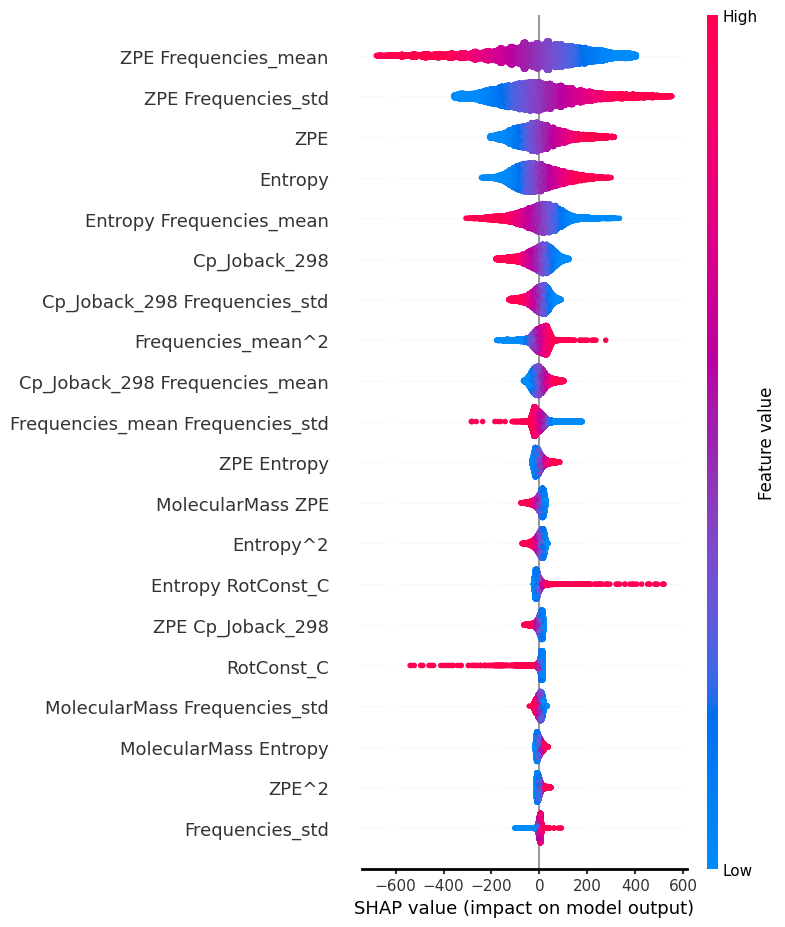

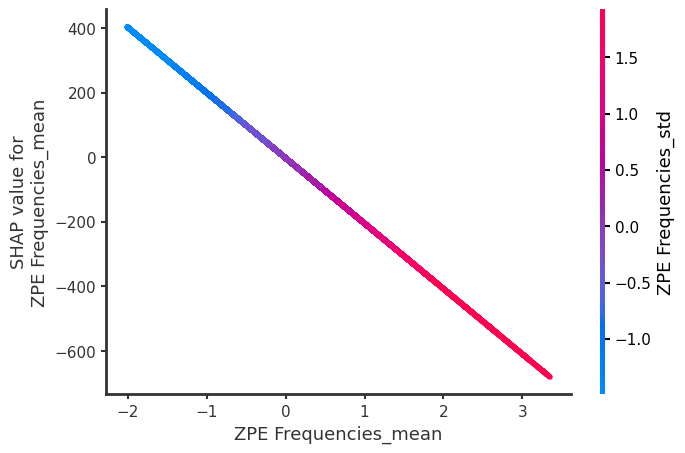

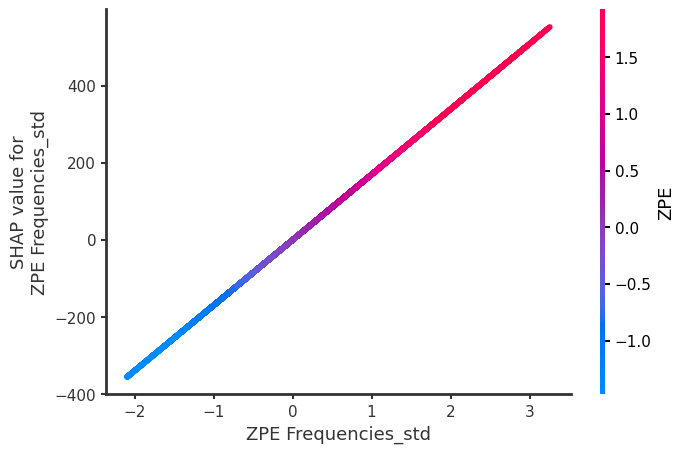

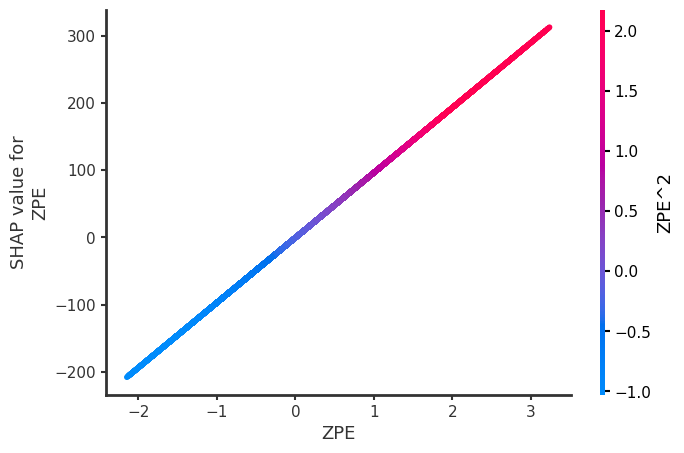

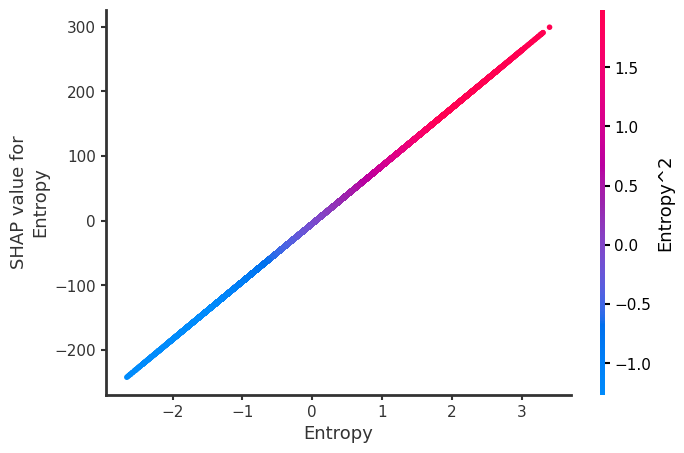


=== LOCAL SHAP EXPLANATION FOR SAMPLE 0 ===


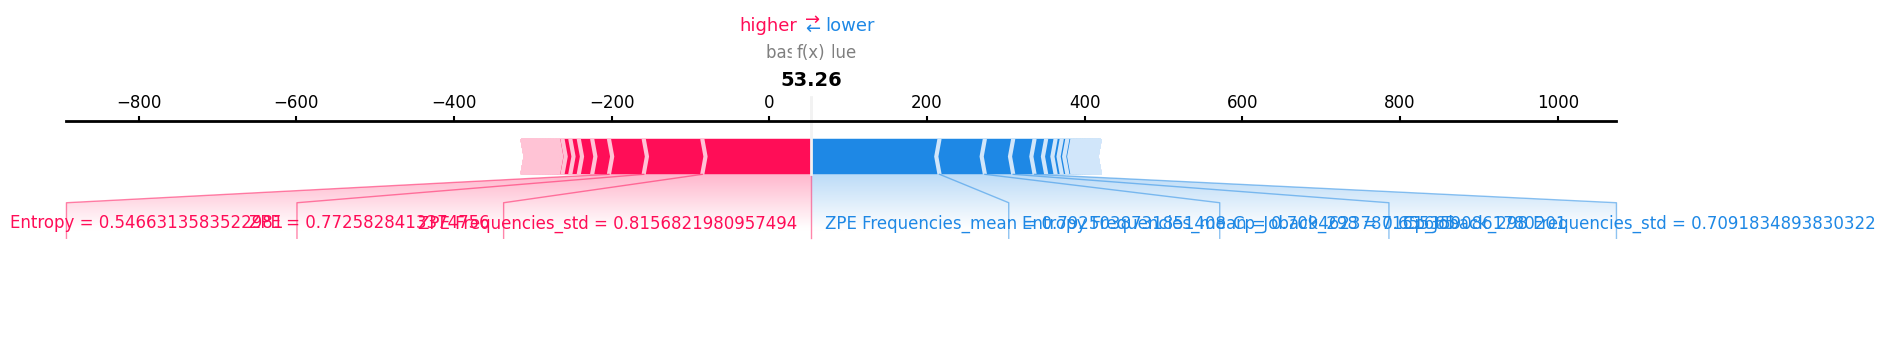

In [ ]:
# SHAP STUDY (INTERPRETABILITY)
print("\n==============================")
print(" SHAP STUDY - MODEL EXPLANATION")
print("==============================")

# Gunakan sebagian data train
X_shap = X_tr[:50000] if X_tr.shape[0] > 50000 else X_tr

# LinearRegression → pakai LinearExplainer
explainer = shap.LinearExplainer(teacher, X_shap)
shap_values = explainer(X_shap)

# GLOBAL FEATURE IMPORTANCE
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

df_shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print("\n=== TOP 15 GLOBAL SHAP FEATURES ===")
print(df_shap_importance.head(15))

# SUMMARY PLOT
shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=feature_names,
    max_display=20,
    show=True,
)

# DEPENDENCE PLOT (TOP 4 FEATURES)
top_features = df_shap_importance["Feature"].head(4).tolist()

for feat in top_features:
    shap.dependence_plot(
        feat,
        shap_values.values,
        X_shap,
        feature_names=feature_names,
        show=True,
    )

# LOCAL EXPLANATION (1 SAMPLE)
sample_idx = 0

print(f"\n=== LOCAL SHAP EXPLANATION FOR SAMPLE {sample_idx} ===")

shap.force_plot(
    explainer.expected_value,
    shap_values.values[sample_idx],
    X_shap[sample_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=True
)

In [ ]:
# INFORMASI MODEL (WHITE BOX)
print("\n=== INFORMASI MODEL POLYNOMIAL ===")
print("Jumlah fitur awal (fingerprint + fisik)       :", X_teacher_raw.shape[1])
print("Jumlah fitur polynomial deskriptor fisik     :", X_phys_poly.shape[1])
print("Derajat polinomial deskriptor fisik          : 2")

# FEATURE NAMES
# Fingerprint feature names
fp_names = [f"FP_{i}" for i in range(X_fp_vt.shape[1])]

# Polynomial physical descriptor names
phys_base = [
    "MolecularMass",
    "ZPE",
    "Entropy",
    "Cp_Joback_298",
    "Frequencies_mean",
    "Frequencies_std",
    "ReducedMasses_mean",
    "ReducedMasses_std",
    "RotConst_A",
    "RotConst_B",
    "RotConst_C",
    "SymNumber"
]
poly = PolynomialFeatures(degree=2, include_bias=False)
X_phys_poly = poly.fit_transform(X_phys)
poly_names = poly.get_feature_names_out(phys_base)

# Gabungkan
feature_names = fp_names + list(poly_names)

# COEFFICIENTS
coefficients = teacher.coef_

df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsCoefficient": np.abs(coefficients)
})

# Urutkan dari paling penting
df_importance = df_importance.sort_values(
    by="AbsCoefficient",
    ascending=False
)

df_importance.head(15)

# EXPLICIT POLYNOMIAL EQUATION
intercept = teacher.intercept_
coefs = teacher.coef_

equation_terms = []

for name, coef in zip(feature_names, coefs):
    if abs(coef) > 1e1:
        equation_terms.append(f"({coef:.4e})·{name}")

equation = "Cp = {:.4e}".format(intercept) + " + \\\n     ".join(equation_terms)

print("\n=== EXPLICIT MODEL EQUATION ===\n")
print(equation)


=== INFORMASI MODEL POLYNOMIAL ===
Jumlah fitur awal (fingerprint + fisik)       : 219
Jumlah fitur polynomial deskriptor fisik     : 90
Derajat polinomial deskriptor fisik          : 2

=== EXPLICIT MODEL EQUATION ===

Cp = 4.9874e+01(9.6729e+01)·ZPE + \
     (8.9399e+01)·Entropy + \
     (-5.5652e+01)·Cp_Joback_298 + \
     (1.0877e+01)·Frequencies_std + \
     (-1.7089e+01)·RotConst_C + \
     (-1.8019e+01)·MolecularMass ZPE + \
     (1.0147e+01)·MolecularMass Entropy + \
     (-1.1229e+01)·MolecularMass Frequencies_std + \
     (1.0371e+01)·ZPE^2 + \
     (1.9605e+01)·ZPE Entropy + \
     (-1.4264e+01)·ZPE Cp_Joback_298 + \
     (-2.0253e+02)·ZPE Frequencies_mean + \
     (1.6972e+02)·ZPE Frequencies_std + \
     (-1.7520e+01)·Entropy^2 + \
     (-8.6234e+01)·Entropy Frequencies_mean + \
     (1.9900e+01)·Entropy RotConst_C + \
     (2.9837e+01)·Cp_Joback_298 Frequencies_mean + \
     (-3.8691e+01)·Cp_Joback_298 Frequencies_std + \
     (3.7702e+01)·Frequencies_mean^2 + \
     (-3

In [ ]:
# DATASET STUDENT (KNOWLEDGE DISTILLATION)
X_fp_only = X_fp_vt

# Pisahkan fingerprint dan fisik
n_fp = X_fp_vt.shape[1]
X_teacher_fp = X_teacher_raw[:, :n_fp]
X_teacher_phys = X_teacher_raw[:, n_fp:]

X_teacher_all = scaler_teacher.transform(X_teacher_raw)
y_teacher = teacher.predict(X_teacher_all)

# Student dataset: hanya fingerprint
X_student = X_fp_vt

# Split train/test student
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_student, y_teacher, test_size=0.2, random_state=SEED
)

# Scaling fingerprint untuk ANN
scaler_student = StandardScaler()
X_tr_s = scaler_student.fit_transform(X_tr_s)
X_te_s = scaler_student.transform(X_te_s)

In [ ]:
# RF SMILES + DESKRIPTOR FISIK (MODEL DEPLOYABLE)
# Gabungkan fingerprint + fitur fisik polynomial
X_student = X_fp_vt

# Split train/test
idx = np.arange(len(X_student))

X_tr_s, X_te_s, y_tr_s, y_te_s, idx_tr, idx_te = train_test_split(
    X_student, y_teacher, idx, test_size=0.2, random_state=SEED
)

# Scaling untuk RF
scaler_student = StandardScaler()
X_tr_s = scaler_student.fit_transform(X_tr_s)
X_te_s = scaler_student.transform(X_te_s)

# RANDOM FOREST STUDENT MODEL
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=2,
    max_features=0.3,
    random_state=SEED,
    n_jobs=-1
)

model.fit(X_tr_s, y_tr_s)

RandomForestRegressor(max_depth=15, max_features=0.3, min_samples_leaf=2,
                      n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:
# EVALUASI STUDENT MODEL (ΔCp TEACHER vs ΔCp STUDENT)
yp = model.predict(X_te_s)

print("\n=== PERFORMA STUDENT (ΔCp Student vs ΔCp Teacher) ===")
print("RMSE:", np.sqrt(mean_squared_error(y_te_s, yp)))
print("R2  :", r2_score(y_te_s, yp))

# REKONSTRUKSI Cp FINAL & EVALUASI
# Ambil Cp Joback dan Cp True yang SESUAI dengan test-set student
cp_joback_test = df.loc[idx_te, "Cp_Joback_298"].values
cp_true        = df.loc[idx_te, "Cp_CHAOS_298"].values

# Hybrid final prediction (Cp_final = Cp_Joback + ΔCp_student)
cp_final = cp_joback_test + yp

print("\n=== PERFORMA AKHIR (Cp_true vs Cp_final = Cp_Joback + ΔCp_student) ===")
print("MAE :", mean_absolute_error(cp_true, cp_final))
print("RMSE:", np.sqrt(mean_squared_error(cp_true, cp_final)))
print("R2  :", r2_score(cp_true, cp_final))

# PARITY PLOT — ΔCp: TEACHER vs STUDENT
import plotly.graph_objects as go

FILL_COLORS = [
    "#17A4B8",
    "#A9BF4F",
    "#F3D18D",
    "#9A5A7F",
    "#4274B0",
    "#6C6278",
]

def base_layout(title: str, x_title: str = "", y_title: str = "") -> dict:
    return dict(
        title=dict(text=title, x=0.5, xanchor="center"),
        xaxis=dict(title=x_title, showline=True, linewidth=2, linecolor="black", mirror=True),
        yaxis=dict(title=y_title, showline=True, linewidth=2, linecolor="black", mirror=True),
        font=dict(family="Arial", size=14),
        width=600,
        height=600,
        plot_bgcolor="white",
        paper_bgcolor="white",
    )

# Parity Plot
mn = float(np.min([y_te_s.min(), yp.min()]))
mx = float(np.max([y_te_s.max(), yp.max()]))

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=y_te_s,
        y=yp,
        mode="markers",
        name="Test data",
        marker=dict(
            color=FILL_COLORS[0],
            size=7,
            opacity=0.7,
            line=dict(color="black", width=0.8),
        ),
    )
)
fig.add_trace(
    go.Scatter(
        x=[mn, mx],
        y=[mn, mx],
        mode="lines",
        name="y = x",
        line=dict(color="black", width=2, dash="dash"),
    )
)
fig.update_layout(
    **base_layout(
        title="Parity Plot – ΔCp Student vs ΔCp Teacher",
        x_title="ΔCp Teacher (cal/mol/K)",
        y_title="ΔCp Prediksi Student (cal/mol/K)",
    ),
    legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
)
fig.update_xaxes(
    range=[mn, mx],
    tickmode="linear",
    tick0=0,
    dtick=20
)
fig.update_yaxes(
    range=[mn, mx],
    tickmode="linear",
    tick0=0,
    dtick=20
)
fig.show()

# PARITY PLOT — Cp: TRUE vs FINAL HYBRID (HIGHLIGHT 5 TITIK)
highlight_idx = np.arange(min(5, len(cp_true)))

mn = float(np.min([cp_true.min(), cp_final.min()]))
mx = float(np.max([cp_true.max(), cp_final.max()]))

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=cp_true,
        y=cp_final,
        mode="markers",
        name="All test points",
        marker=dict(
            color=FILL_COLORS[4],
            size=7,
            opacity=0.7,
            line=dict(color="black", width=0.6),
        ),
    )
)
fig.add_trace(
    go.Scatter(
        x=cp_true[highlight_idx],
        y=cp_final[highlight_idx],
        mode="markers",
        name="Highlighted 5 molecules",
        marker=dict(
            color="orange",
            size=14,
            line=dict(color="black", width=2),
        ),
    )
)

# Garis y=x
fig.add_trace(
    go.Scatter(
        x=[mn, mx],
        y=[mn, mx],
        mode="lines",
        name="y = x",
        line=dict(color="black", width=2, dash="dash"),
    )
)

fig.update_layout(
    **base_layout(
        title="Parity Plot – Cp Final Hybrid vs Cp True (5 highlighted)",
        x_title="Cp CHAOS (cal/mol/K)",
        y_title="Cp Final = Cp_Joback + ΔCp_student (cal/mol/K)",
    ),
    legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
)
fig.update_xaxes(
    range=[mn, mx],
    tickmode="linear",
    tick0=0,
    dtick=50
)
fig.update_yaxes(
    range=[mn, mx],
    tickmode="linear",
    tick0=0,
    dtick=50
)
fig.show()

# CEK KONSISTENSI INDEX
print("\n=== CEK KONSISTENSI INDEX TEST ===")
print("Contoh 5 index test       :", idx_te[:5])
print("Contoh Cp_joback_test    :", cp_joback_test[:5])
print("Contoh Cp_true           :", cp_true[:5])
print("Contoh ΔCp teacher       :", y_te_s[:5])
print("Contoh ΔCp student       :", yp[:5])
print("Panjang idx_te           :", len(idx_te))
print("Panjang yp               :", len(yp))
print("Panjang cp_joback_test   :", len(cp_joback_test))
print("Panjang cp_true          :", len(cp_true))

# TAMPILKAN 5 MOLEKUL CONTOH
print("\n=== 5 CONTOH MOLEKUL (SMILES, Cp_true, Cp_final) ===")

# Ambil 5 index df yang sesuai dengan highlight_idx
df_indices_5 = idx_te[highlight_idx]

# Ambil data dari dataframe asli
smiles_5   = df.loc[df_indices_5, "CanonicalSMILES"].values
cp_true_5  = cp_true[highlight_idx]
cp_final_5 = cp_final[highlight_idx]

for i in range(len(df_indices_5)):
    print(f"\nMolekul {i+1}")
    print("Index df   :", df_indices_5[i])
    print("SMILES     :", smiles_5[i])
    print("Cp_true    :", cp_true_5[i])
    print("Cp_final   :", cp_final_5[i])
    print("Error      :", cp_final_5[i] - cp_true_5[i])


=== PERFORMA STUDENT (ΔCp Student vs ΔCp Teacher) ===
RMSE: 15.631883072033812
R2  : 0.6992970980922542

=== PERFORMA AKHIR (Cp_true vs Cp_final = Cp_Joback + ΔCp_student) ===
MAE : 11.77473166374799
RMSE: 15.741639815707448
R2  : 0.9597126520322967



=== CEK KONSISTENSI INDEX TEST ===
Contoh 5 index test       : [47441 41493  2531 15625 19603]
Contoh Cp_joback_test    : [ 89.61578439 163.32571705 152.4574062  218.81314455 136.42204853]
Contoh Cp_true           : [158.397872 182.497712 200.124904 251.977216 237.216064]
Contoh ΔCp teacher       : [ 67.39972323  19.17291176  46.45478185  33.63969157 103.46504289]
Contoh ΔCp student       : [76.80377886 24.82336105 59.51319382 34.37798227 98.43352844]
Panjang idx_te           : 9761
Panjang yp               : 9761
Panjang cp_joback_test   : 9761
Panjang cp_true          : 9761

=== 5 CONTOH MOLEKUL (SMILES, Cp_true, Cp_final) ===

Molekul 1
Index df   : 47441
SMILES     : N#Cc1ccc(S(=O)(=O)Cl)cc1
Cp_true    : 158.397872
Cp_final   : 166.41956324777027
Error      : 8.021691247770264

Molekul 2
Index df   : 41493
SMILES     : CCOC(=O)C(=O)C(Cl)CC
Cp_true    : 182.497712
Cp_final   : 188.14907810090446
Error      : 5.651366100904454

Molekul 3
Index df   : 2531
SMILES     : COc1ccc(CC(O)

In [ ]:
#Interface Cp Prediction using SMILE only
from rdkit import Chem

def smiles_to_fp(smiles):
    """
    Convert SMILES -> Morgan fingerprint
    Menggunakan fungsi mol_to_morgan_fp yang SUDAH ADA di pipeline training
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    fp = mol_to_morgan_fp(mol)   # pakai fungsi lama kamu
    return fp

def predict_cp_from_smiles(smiles, T_C=None):
    """
    Input  : smiles (string)
    Output : dict berisi Cp_joback, ΔCp_student, Cp_final, Cp_true (jika ada)
    """
    # Hitung fingerprint
    fp_raw = smiles_to_fp(smiles)
    fp_raw = fp_raw.reshape(1, -1)

    # Apply VarianceThreshold
    fp_vt = vt.transform(fp_raw)

    # Scaling fingerprint
    fp_scaled = scaler_student.transform(fp_vt)

    # Prediksi ΔCp_student
    delta_cp_student = model.predict(fp_scaled)[0]

    # Hitung Cp_Joback dari SMILES dan Cari Cp_true dari fingerprint
    try:
        cp_joback = cp_joback_from_smiles(smiles)
    except:
        cp_joback = None

    cp_true = None

    # Cari Cp_true berdasarkan fingerprint di SELURUH dataset
    try:
        matches = np.all(X_fp_vt == fp_vt, axis=1)
        if np.any(matches):
            idx_match = np.where(matches)[0][0]
            cp_true = df.iloc[idx_match]["Cp_CHAOS_298"]
        else:
            cp_true = None
    except:
        cp_true = None

    # Hitung Cp_final
    if cp_joback is not None:
        cp_final = cp_joback + delta_cp_student
    else:
        cp_final = None

    # Return hasil
    result = {
        "SMILES"         : smiles,
        "DeltaCp_student": float(delta_cp_student),
        "Cp_Joback"     : None if cp_joback is None else float(cp_joback),
        "Cp_final"      : None if cp_final is None else float(cp_final),
        "Cp_true"       : None if cp_true is None else float(cp_true),
        "Error"         : None if (cp_true is None or cp_final is None) else float(cp_final - cp_true)
    }

    return result

In [ ]:
smiles_list = [
    "C(=O)(O)C1=CC=C(C=C1)C=1C=NC=C(C1)C1=CC=C(C=C1)C(=O)O",
    "C(=O)(O)C1=CC=C(C=C1)C=1C(=NC(=C(N1)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C(=O)O)C=C1",
    "S1C(=CC=C1C(=O)O)C(=O)O",
    "C(=O)O",
    "N=1N=C(NC1C=1C=C(C=C(C1)C(=O)O)C(=O)O)C=1C=C(C=C(C1)C(=O)O)C(=O)O",
    "C(#CC=1C=C(C=C(C(=O)O)C1)C(=O)O)C=1C=C(C=C(C(=O)O)C1)C(=O)O"
]

T_list_C = [
    85.0,
    85.0,
    120.0,
    70.0,
    70.0,
    65.0,
]

for smi, T_C in zip(smiles_list, T_list_C):
    print("="*80)
    print(f"Processing SMILES: {smi}")
    print(f"Temperature      : {T_C:.2f} °C")

    try:
        res = predict_cp_from_smiles(smi, T_C)

        print("ΔCp_student :", res["DeltaCp_student"])
        print("Cp_Joback   :", res["Cp_Joback"])
        print("Cp_final    :", res["Cp_final"])
        print("Cp_true     :", res["Cp_true"])

        if res["Error"] is not None:
            print("Error       :", res["Error"])
        else:
            print("Note        : Molecule not found in df, no Cp_true available")

    except Exception as e:
        print("ERROR:", e)

Processing SMILES: C(=O)(O)C1=CC=C(C=C1)C=1C=NC=C(C1)C1=CC=C(C=C1)C(=O)O
Temperature      : 85.00 °C
ΔCp_student : 54.4059977533509
Cp_Joback   : 229.3664209846629
Cp_final    : 283.7724187380138
Cp_true     : None
Note        : Molecule not found in df, no Cp_true available
Processing SMILES: C(=O)(O)C1=CC=C(C=C1)C=1C(=NC(=C(N1)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C(=O)O)C=C1
Temperature      : 85.00 °C
ΔCp_student : 57.03230809466657
Cp_Joback   : 399.98968602042737
Cp_final    : 457.02199411509395
Cp_true     : None
Note        : Molecule not found in df, no Cp_true available
Processing SMILES: S1C(=CC=C1C(=O)O)C(=O)O
Temperature      : 120.00 °C
ΔCp_student : 43.13671597123365
Cp_Joback   : 107.50561801665401
Cp_final    : 150.64233398788767
Cp_true     : 145.795664
Error       : 4.8466699878876796
Processing SMILES: C(=O)O
Temperature      : 70.00 °C
ΔCp_student : 17.17856221817423
Cp_Joback   : 37.54114867049287
Cp_final    : 54.7197108886671
Cp_true     : 35.789936000

In [ ]:
# INTERFACE INFERENCE OTOMATIS: INPUT HANYA SMILES

# Fungsi konversi SMILES → fingerprint
def smiles_to_fp(smiles, radius=2, n_bits=256):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("SMILES tidak valid")
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# SMILES TO GRAPH
def mol_to_graph_data_obj(mol, global_features=None):
    # --- Node features ---
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),
            int(atom.GetIsAromatic()),
            int(atom.GetHybridization()==Chem.rdchem.HybridizationType.SP),
            int(atom.GetHybridization()==Chem.rdchem.HybridizationType.SP2),
            int(atom.GetHybridization()==Chem.rdchem.HybridizationType.SP3),
            int(atom.IsInRing())
        ])
    x = torch.tensor(atom_features, dtype=torch.float)

    # --- Edge index ---
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i,j],[j,i]]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    # --- Global features ---
    if global_features is not None:
        g = torch.tensor(global_features, dtype=torch.float).unsqueeze(0)
    else:
        g = None

    return Data(x=x, edge_index=edge_index, global_attr=g)

In [ ]:
# DATASET GNN (TARGET: ENTROPY)
df = pd.read_excel("/content/chaos_data.xlsx")
print(df.head())

# Simpan nilai asli
df_orig = df[["Entropy"]].copy()

# Normalisasi ENTROPY
scaler_entropy = StandardScaler()
df["Entropy_scaled"] = scaler_entropy.fit_transform(df[["Entropy"]])

class GNNDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.df = df.reset_index(drop=True)

    def len(self):
        return len(self.df)

    def get(self, idx):
        smi = self.df.loc[idx,"CanonicalSMILES"]
        mol = Chem.MolFromSmiles(smi)

        global_features = [
            self.df.loc[idx,"MolecularMass"],
            self.df.loc[idx,"SymNumber"],
            self.df.loc[idx,"RotConst_A"],
            self.df.loc[idx,"RotConst_B"],
            self.df.loc[idx,"RotConst_C"],
            self.df.loc[idx,"Frequencies_mean"],
            self.df.loc[idx,"Frequencies_std"],
            self.df.loc[idx,"ReducedMasses_mean"],
            self.df.loc[idx,"ReducedMasses_std"],
            self.df.loc[idx,"HeatCap"],
            self.df.loc[idx,"SCFEnergy"],
            self.df.loc[idx,"HOMOEnergy"],
            self.df.loc[idx,"LUMOEnergy"],
            self.df.loc[idx,"HLG"],
            self.df.loc[idx,"DipoleMoment"],
            self.df.loc[idx,"PolarIso"],
            self.df.loc[idx,"PolarAniso"]
        ]

        data = mol_to_graph_data_obj(mol, global_features)

        # TARGET
        data.y = torch.tensor([[
           self.df.loc[idx,"Entropy_scaled"]
        ]], dtype=torch.float)

        return data

                          CanonicalSMILES  MolecularMass  SymNumber  \
0              CC(C)(CCCCCCCC(=O)O)C(=O)O      230.15181          1   
1                      CCCCOC(OCCCC)N(C)C      203.18853          1   
2           FC(F)C(F)(F)CC(F)C(F)(F)C(F)F      248.02475          1   
3  CC(C)(C)c1ccc2c(c1)C1=C(CC2)C(=O)OC1=O      256.10994          1   
4   CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O      308.10486          1   

   RotConst_A  RotConst_B  RotConst_C  Frequencies_mean  Frequencies_std  \
0    0.736496    0.381395    0.300476       1374.393855       994.916932   
1    0.678175    0.426082    0.320714       1422.522284       997.833903   
2    1.173707    0.287711    0.276396        985.188957       832.194990   
3    0.762259    0.236580    0.189854       1276.195937       933.636735   
4    0.357589    0.202771    0.160545       1228.896401       929.205603   

   ReducedMasses_mean  ReducedMasses_std  ...        HLG  DipoleMoment  \
0            2.020410           1.320049  

In [ ]:
#MODEL GNN (ENTROPY)
class GNN(nn.Module):
    def __init__(self, node_in_feats, global_in_feats):
        super().__init__()
        self.conv1 = GCNConv(node_in_feats, 64)
        self.conv2 = GCNConv(64, 64)
        self.global_mlp = nn.Linear(global_in_feats, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index, g = data.x, data.edge_index, data.global_attr

        # Node-level GCN
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        # Pool node features ke satu vektor per graph
        batch = data.batch
        x = global_mean_pool(x, batch)

        # Tambahkan global features
        if g is not None:
            x = x + self.global_mlp(g)

        # Output
        out = self.out(x)
        return out

In [ ]:
#TRAINING GNN DENGAN EARLY STOPPING
dataset = GNNDataset(df)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_loader = DataLoader(GNNDataset(train_df), batch_size=32, shuffle=True)
test_loader  = DataLoader(GNNDataset(test_df), batch_size=32)

node_in_feats = 6
global_in_feats = 17
gnn = GNN(node_in_feats, global_in_feats).to(DEVICE)
optimizer = torch.optim.Adam(gnn.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, verbose=True
)
# Early stopping parameters
best_val_loss = np.inf
best_epoch = 0
patience = 20
counter = 0
max_epochs = 200

train_losses = []
val_losses = []

for epoch in range(max_epochs):
    # TRAINING
    gnn.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        pred = gnn(batch)
        loss = loss_fn(pred, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gnn.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # VALIDATION
    gnn.eval()
    val_loss_total = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(DEVICE)
            pred = gnn(batch)
            val_loss_total += loss_fn(pred, batch.y).item()
    val_loss = val_loss_total / len(test_loader)
    scheduler.step(val_loss)
    val_losses.append(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:03d} | LR: {current_lr:.2e}")
    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # EARLY STOPPING
    min_delta = 1e-4
    warmup_epochs = 20

    # Warm-up phase
    if epoch < warmup_epochs:
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            torch.save(gnn.state_dict(), "best_gnn.pt")
        continue

    # Setelah warm-up, pakai kriteria min_delta
    if best_val_loss - val_loss > min_delta:
        best_val_loss = val_loss
        best_epoch = epoch
        counter = 0
        torch.save(gnn.state_dict(), "best_gnn.pt")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

# LOAD BEST MODEL
gnn.load_state_dict(torch.load("best_gnn.pt"))
print("Best model loaded with Val Loss:", best_val_loss)

print("Best model loaded from epoch:", best_epoch)
print("Best Val Loss:", best_val_loss)

#learning curve GNN
import plotly.graph_objects as go

FILL_COLORS = [
    "#17A4B8",
    "#A9BF4F",
    "#F3D18D",
    "#9A5A7F",
    "#4274B0",
    "#6C6278",
]

def base_layout(title: str, x_title: str = "", y_title: str = "") -> dict:
    return dict(
        title=dict(text=title, x=0.5, xanchor="center"),
        xaxis=dict(title=x_title, showline=True, linewidth=2, linecolor="black", mirror=True),
        yaxis=dict(title=y_title, showline=True, linewidth=2, linecolor="black", mirror=True),
        font=dict(family="Arial", size=14),
        width=600,
        height=600,
        plot_bgcolor="white",
        paper_bgcolor="white",
    )

epochs = list(range(len(train_losses)))

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=epochs,
        y=train_losses,
        mode="lines+markers",
        name="Train Loss",
        line=dict(color=FILL_COLORS[4], width=2),
        marker=dict(size=5, line=dict(color="black", width=0.6)),
    )
)
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=val_losses,
        mode="lines+markers",
        name="Val Loss",
        line=dict(color=FILL_COLORS[5], width=2),
        marker=dict(size=5, line=dict(color="black", width=0.6)),
    )
)
fig.update_layout(
    **base_layout(
        title="Training Curve GNN (Entropy)",
        x_title="Epoch",
        y_title="MSE Loss (scaled Entropy)",
    ),
    legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
)
fig.show()

Epoch 000 | LR: 1.00e-04
Epoch 000 | Train Loss: 1792.0559 | Val Loss: 0.1446
Epoch 001 | LR: 1.00e-04
Epoch 001 | Train Loss: 0.2225 | Val Loss: 0.0609
Epoch 002 | LR: 1.00e-04
Epoch 002 | Train Loss: 0.2249 | Val Loss: 0.1167
Epoch 003 | LR: 1.00e-04
Epoch 003 | Train Loss: 0.2095 | Val Loss: 0.3485
Epoch 004 | LR: 1.00e-04
Epoch 004 | Train Loss: 0.2121 | Val Loss: 0.2211
Epoch 005 | LR: 1.00e-04
Epoch 005 | Train Loss: 0.2465 | Val Loss: 0.0640
Epoch 006 | LR: 1.00e-04
Epoch 006 | Train Loss: 0.1930 | Val Loss: 0.0448
Epoch 007 | LR: 1.00e-04
Epoch 007 | Train Loss: 0.2302 | Val Loss: 0.3752
Epoch 008 | LR: 1.00e-04
Epoch 008 | Train Loss: 0.2126 | Val Loss: 0.2509
Epoch 009 | LR: 1.00e-04
Epoch 009 | Train Loss: 0.2080 | Val Loss: 0.0692
Epoch 010 | LR: 1.00e-04
Epoch 010 | Train Loss: 0.2152 | Val Loss: 0.0668
Epoch 011 | LR: 1.00e-04
Epoch 011 | Train Loss: 0.2038 | Val Loss: 0.1332
Epoch 012 | LR: 5.00e-05
Epoch 012 | Train Loss: 0.2055 | Val Loss: 0.0849
Epoch 013 | LR: 5.00e-

In [ ]:
#learning curve GNN
import plotly.graph_objects as go

FILL_COLORS = [
    "#17A4B8",
    "#A9BF4F",
    "#F3D18D",
    "#9A5A7F",
    "#4274B0",
    "#6C6278",
]

def base_layout(title: str, x_title: str = "", y_title: str = "") -> dict:
    return dict(
        title=dict(text=title, x=0.5, xanchor="center"),
        xaxis=dict(
            title=x_title,
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=True,
        ),
        yaxis=dict(
            title=y_title,
            type="log",
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=True,
            minor=dict(
                ticks="outside",
                showgrid=True
            ),
            showgrid=True
        ),
        font=dict(family="Arial", size=14),
        width=600,
        height=600,
        plot_bgcolor="white",
        paper_bgcolor="white",
    )


epochs = list(range(len(train_losses)))

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=epochs,
        y=train_losses,
        mode="lines",
        name="Train Loss",
        line=dict(color=FILL_COLORS[4], width=4),
        marker=dict(size=5, line=dict(color="black", width=0.6)),
    )
)
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=val_losses,
        mode="lines",
        name="Val Loss",
        line=dict(color=FILL_COLORS[0], width=4),
        marker=dict(size=5, line=dict(color="black", width=0.6)),
    )
)

fig.update_layout(
    **base_layout(
        title="Training Curve GNN (Entropy)",
        x_title="Epoch",
        y_title="MSE Loss (scaled Entropy)",
    ),
    legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
)

fig.show()

In [ ]:
#Embedding Molekul (t-SNE) GNN
def get_gnn_embedding(model, loader):
    embs = []
    ys = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)

            x, edge_index, g = batch.x, batch.edge_index, batch.global_attr

            x = F.relu(model.conv1(x, edge_index))
            x = F.relu(model.conv2(x, edge_index))

            x = global_mean_pool(x, batch.batch)

            if g is not None:
                x = x + model.global_mlp(g)

            embs.append(x.cpu().numpy())
            ys.append(batch.y.cpu().numpy())

    return np.vstack(embs), np.vstack(ys)

#Visualisasi
from sklearn.manifold import TSNE

embs, ys = get_gnn_embedding(gnn, test_loader)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
Z = tsne.fit_transform(embs)

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=Z[:, 0],
        y=Z[:, 1],
        mode="markers",
        marker=dict(
            size=7,
            color=ys[:, 0],
            colorscale="Viridis",
            opacity=0.85,
            line=dict(color="black", width=0.5),
            colorbar=dict(title="Entropy (scaled)")
        ),
        name="Embedding"
    )
)

fig.update_layout(
    **base_layout(
        title="t-SNE of GNN Molecular Embeddings",
        x_title="t-SNE 1",
        y_title="t-SNE 2",
    )
)

fig.show()


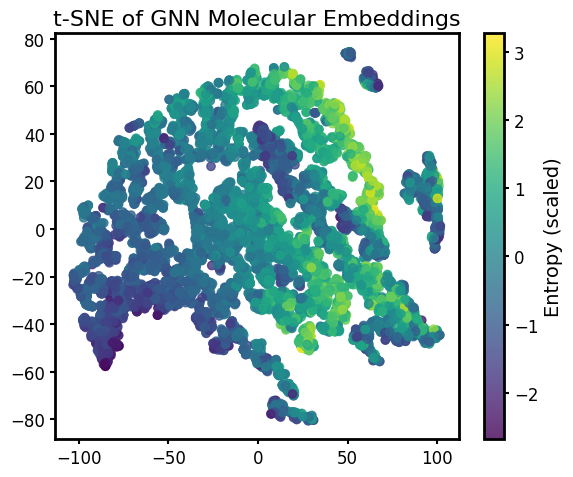

In [ ]:
#Embedding Molekul (t-SNE) GNN
def get_gnn_embedding(model, loader):
    embs = []
    ys = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)

            x, edge_index, g = batch.x, batch.edge_index, batch.global_attr

            x = F.relu(model.conv1(x, edge_index))
            x = F.relu(model.conv2(x, edge_index))

            x = global_mean_pool(x, batch.batch)

            if g is not None:
                x = x + model.global_mlp(g)

            embs.append(x.cpu().numpy())
            ys.append(batch.y.cpu().numpy())

    return np.vstack(embs), np.vstack(ys)

#Visualisasi
from sklearn.manifold import TSNE

embs, ys = get_gnn_embedding(gnn, test_loader)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
Z = tsne.fit_transform(embs)

plt.figure(figsize=(6,5))
sc = plt.scatter(Z[:,0], Z[:,1], c=ys[:,0], cmap="viridis", alpha=0.8)
plt.colorbar(sc, label="Entropy (scaled)")
plt.title("t-SNE of GNN Molecular Embeddings")
plt.tight_layout()
plt.show()

In [ ]:
# EVALUASI GNN (ENTROPY)
def eval_gnn(model, loader):
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            out = model(batch)

            y_true.append(batch.y.view(-1,1).cpu().numpy())
            y_pred.append(out.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)
    return y_true, y_pred

y_true_scaled, y_pred_scaled = eval_gnn(gnn, test_loader)

# Kembalikan ke skala asli
y_true = scaler_entropy.inverse_transform(y_true_scaled)
y_pred = scaler_entropy.inverse_transform(y_pred_scaled)

print("Entropy MAE :", mean_absolute_error(y_true, y_pred))
print("Entropy RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("Entropy R2  :", r2_score(y_true, y_pred))

# Bandingkan nilai entropy asli vs prediksi
def unnormalize_targets(y_scaled, scaler_entropy):
    """
    Sekarang hanya ada 1 target = Entropy
    Return shape (N,1)
    """
    entropy = scaler_entropy.inverse_transform(
        y_scaled.reshape(-1,1)
    ).flatten()

    return entropy.reshape(-1, 1)

# Evaluasi GNN (masih dalam skala normalisasi)
y_true_scaled, y_pred_scaled = eval_gnn(gnn, test_loader)

# Kembalikan ke skala asli menggunakan scaler terpisah
y_true = unnormalize_targets(y_true_scaled, scaler_entropy)
y_pred = unnormalize_targets(y_pred_scaled, scaler_entropy)

# Hitung metrik
entropy_mae  = mean_absolute_error(y_true[:,0], y_pred[:,0])
entropy_rmse = np.sqrt(mean_squared_error(y_true[:,0], y_pred[:,0]))
entropy_r2   = r2_score(y_true[:,0], y_pred[:,0])

print("=== Evaluasi GNN di Skala Asli (Entropy Only) ===")
print(f"Entropy  -> MAE: {entropy_mae:.4f}, RMSE: {entropy_rmse:.4f}, R2: {entropy_r2:.4f}")

# Bandingkan nilai asli vs prediksi
print("\n=== Contoh Perbandingan 5 Sampel Pertama (Entropy) ===")
for i in range(5):
    smi = test_df.iloc[i]["CanonicalSMILES"]
    print(f"{i+1}: SMILES={smi}")
    print(f"   Entropy asli={y_true[i,0]:.2f}, Entropy pred={y_pred[i,0]:.2f}")
    print("-"*60)

# visualisasi
def base_layout(title: str, x_title: str = "", y_title: str = "") -> dict:
    return dict(
        title=dict(text=title, x=0.5, xanchor="center"),
        xaxis=dict(
            title=x_title,
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=True,
            showgrid=True
        ),
        yaxis=dict(
            title=y_title,
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=True,
            showgrid=True
        ),
        font=dict(family="Arial", size=14),
        width=700,
        height=700,
        plot_bgcolor="white",
        paper_bgcolor="white",
    )


def plot_gnn_entropy_pred(y_true, y_pred):
    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=y_true.flatten(),
            y=y_pred.flatten(),
            mode="markers",
            name="Test data",
            marker=dict(
                color=FILL_COLORS[4],
                size=7,
                opacity=0.6,
                line=dict(color="black", width=0.8),
            ),
        )
    )
    fig.add_trace(
        go.Scatter(
            x=y_true[:5].flatten(),
            y=y_pred[:5].flatten(),
            mode="markers",
            name="First 5 samples",
            marker=dict(
                color="orange",
                size=10,
                line=dict(color="black", width=1.5),
            ),
        )
    )
    mn = float(min(y_true.min(), y_pred.min()))
    mx = float(max(y_true.max(), y_pred.max()))
    fig.add_trace(
        go.Scatter(
            x=[mn, mx],
            y=[mn, mx],
            mode="lines",
            name="y = x",
            line=dict(color="black", width=2, dash="dash"),
        )
    )
    fig.update_layout(
        **base_layout(
            title="GNN Entropy: True vs Predicted",
            x_title="True Entropy (J/mol·K)",
            y_title="Predicted Entropy (J/mol·K)",
        ),
        legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
    )
    fig.update_xaxes(type="linear", range=[mn, mx])
    fig.update_yaxes(type="linear", range=[mn, mx])
    fig.show()

plot_gnn_entropy_pred(y_true, y_pred)

Entropy MAE : 12.738472938537598
Entropy RMSE: 17.335960384730274
Entropy R2  : 0.9725416302680969
=== Evaluasi GNN di Skala Asli (Entropy Only) ===
Entropy  -> MAE: 12.7385, RMSE: 17.3360, R2: 0.9725

=== Contoh Perbandingan 5 Sampel Pertama (Entropy) ===
1: SMILES=N#Cc1ccc(S(=O)(=O)Cl)cc1
   Entropy asli=432.38, Entropy pred=434.60
------------------------------------------------------------
2: SMILES=CCOC(=O)C(=O)C(Cl)CC
   Entropy asli=482.43, Entropy pred=470.93
------------------------------------------------------------
3: SMILES=COc1ccc(CC(O)CCl)cc1
   Entropy asli=476.03, Entropy pred=472.76
------------------------------------------------------------
4: SMILES=CCN1C(=O)N(CC)C2C1N(C)C(=O)N2C
   Entropy asli=546.74, Entropy pred=540.82
------------------------------------------------------------
5: SMILES=CNP(=O)(OC)Oc1ccc(Cl)cc1Cl
   Entropy asli=556.93, Entropy pred=537.62
------------------------------------------------------------


In [ ]:
# FINGERPRINT versi RDKit langsung
def smiles_to_fp(smiles, n_bits=256):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits)
    return fp

# Precompute fingerprint RDKit untuk seluruh dataset
fps_all = []
for smi in df["CanonicalSMILES"]:
    fp = smiles_to_fp(smi, n_bits=256)
    fps_all.append(fp)

df = pd.read_excel("/content/cp_joback_vs_chaos.xlsx")
print(df.columns)

Index(['CanonicalSMILES', 'MolecularMass', 'SymNumber', 'RotConst_A',
       'RotConst_B', 'RotConst_C', 'Frequencies_mean', 'Frequencies_std',
       'ReducedMasses_mean', 'ReducedMasses_std', 'ZPE', 'Entropy', 'HeatCap',
       'SCFEnergy', 'HOMOEnergy', 'LUMOEnergy', 'HLG', 'DipoleMoment',
       'PolarIso', 'PolarAniso', 'Cp_Joback_298', 'Cp_CHAOS_298', 'Cp_Error',
       'Cp_AbsError', 'Cp_RelError_%', 'DeltaCp'],
      dtype='object')


In [ ]:
import time

# PREDIKSI ENTROPY DARI GNN UNTUK SELURUH DF
gnn.eval()
ent_pred = []
bad_graph_idx = []

t0 = time.time()

# Cache mol supaya tidak MolFromSmiles berkali-kali
mol_list = []

for i, s in enumerate(df["CanonicalSMILES"]):
    if i % 1000 == 0:
        elapsed = time.time() - t0
        print(f"[Entropy GNN] {i}/{len(df)} | elapsed {elapsed/60:.1f} min")

    mol = Chem.MolFromSmiles(s)
    mol_list.append(mol)

    if mol is None:
        ent_pred.append(np.nan)
        bad_graph_idx.append(i)
        continue

    global_features = [
        df.loc[i,"MolecularMass"],
        df.loc[i,"SymNumber"],
        df.loc[i,"RotConst_A"],
        df.loc[i,"RotConst_B"],
        df.loc[i,"RotConst_C"],
        df.loc[i,"Frequencies_mean"],
        df.loc[i,"Frequencies_std"],
        df.loc[i,"ReducedMasses_mean"],
        df.loc[i,"ReducedMasses_std"],
        df.loc[i,"HeatCap"],
        df.loc[i,"SCFEnergy"],
        df.loc[i,"HOMOEnergy"],
        df.loc[i,"LUMOEnergy"],
        df.loc[i,"HLG"],
        df.loc[i,"DipoleMoment"],
        df.loc[i,"PolarIso"],
        df.loc[i,"PolarAniso"]
    ]

    try:
        data = mol_to_graph_data_obj(mol, global_features)

        if data.edge_index is None or data.edge_index.size(1) == 0:
            raise ValueError("Graph has no edges")

        data = data.to(DEVICE)
        with torch.no_grad():
            out = gnn(data)

        ent_pred.append(out[0,0].item())

    except Exception:
        ent_pred.append(np.nan)
        bad_graph_idx.append(i)

df["Entropy_pred"] = ent_pred
df = df.dropna(subset=["Entropy_pred"]).reset_index(drop=True)

# Sinkronkan mol_list dengan df yang sudah difilter
mol_list = [mol_list[i] for i in range(len(mol_list)) if i not in bad_graph_idx]

print("[OK] Entropy prediction finished")

# REBUILD FINGERPRINT SETELAH DF DIFILTER
fps_all = []

t0 = time.time()
for i, mol in enumerate(mol_list):
    if i % 2000 == 0:
        elapsed = time.time() - t0
        print(f"[Fingerprint] {i}/{len(df)} | elapsed {elapsed/60:.1f} min")

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=256)
    fps_all.append(fp)

print("[OK] Fingerprint rebuilt")

# Kembalikan ke skala asli
df["Entropy_pred"] = scaler_entropy.inverse_transform(
    df["Entropy_pred"].values.reshape(-1,1)
).flatten()

# ZPE DARI NEAREST NEIGHBOR (TANIMOTO)
def get_zpe_from_nearest_neighbor_fp(fp_query, df, fps_all):
    # fp_query sekarang langsung ExplicitBitVect, bukan bikin ulang dari SMILES
    sims = DataStructs.BulkTanimotoSimilarity(fp_query, fps_all)

    best_idx = int(np.argmax(sims))
    best_sim = float(sims[best_idx])

    zpe_nn = df.loc[best_idx, "ZPE"]
    return zpe_nn, best_idx, best_sim

# PREPARE FEATURE UNTUK MODEL Cp
# MolWt pakai mol_list
X_mass = np.array([
    Descriptors.MolWt(mol) if mol is not None else np.nan
    for mol in mol_list
])

# ZPE dari nearest neighbor
zpe_nn_list = []

t0 = time.time()
N = len(df)

for i, smi in enumerate(df["CanonicalSMILES"]):
    if i % 500 == 0:
        elapsed = time.time() - t0
        rate = elapsed / max(i,1)
        eta = rate * (N - i)
        print(f"[ZPE NN] {i}/{N} | elapsed {elapsed/60:.1f} min | ETA {eta/60:.1f} min")

    # PAKAI fingerprint yang SUDAH ADA
    fp_query = fps_all[i]

    zpe_nn, _, _ = get_zpe_from_nearest_neighbor_fp(fp_query, df, fps_all)
    zpe_nn_list.append(zpe_nn)

zpe_nn_arr = np.array(zpe_nn_list)

print("[OK] ZPE nearest neighbor finished")

# Fingerprint untuk model ML (konversi ke numpy array)
X_fp = np.array([
    np.array(fp) if fp is not None else np.zeros(256)
    for fp in fps_all
])

# Phys features: [mass, ZPE_nn, Entropy_pred]
X_phys = np.column_stack([
    X_mass,
    zpe_nn_arr,
    df["Entropy_pred"].values
])

X = np.hstack([X_fp, X_phys])

# Target Cp = OUTPUT TEACHER (DISTILLATION)
y = y_teacher.copy()

print("[DONE] Feature matrix X and target y ready")

[Entropy GNN] 0/48804 | elapsed 0.0 min
[Entropy GNN] 1000/48804 | elapsed 0.0 min
[Entropy GNN] 2000/48804 | elapsed 0.1 min
[Entropy GNN] 3000/48804 | elapsed 0.1 min
[Entropy GNN] 4000/48804 | elapsed 0.2 min
[Entropy GNN] 5000/48804 | elapsed 0.2 min
[Entropy GNN] 6000/48804 | elapsed 0.2 min
[Entropy GNN] 7000/48804 | elapsed 0.3 min
[Entropy GNN] 8000/48804 | elapsed 0.3 min
[Entropy GNN] 9000/48804 | elapsed 0.4 min
[Entropy GNN] 10000/48804 | elapsed 0.4 min
[Entropy GNN] 11000/48804 | elapsed 0.5 min
[Entropy GNN] 12000/48804 | elapsed 0.5 min
[Entropy GNN] 13000/48804 | elapsed 0.6 min
[Entropy GNN] 14000/48804 | elapsed 0.6 min
[Entropy GNN] 15000/48804 | elapsed 0.6 min
[Entropy GNN] 16000/48804 | elapsed 0.7 min
[Entropy GNN] 17000/48804 | elapsed 0.7 min
[Entropy GNN] 18000/48804 | elapsed 0.8 min
[Entropy GNN] 19000/48804 | elapsed 0.8 min
[Entropy GNN] 20000/48804 | elapsed 0.9 min
[Entropy GNN] 21000/48804 | elapsed 1.0 min
[Entropy GNN] 22000/48804 | elapsed 1.0 min
[

In [ ]:
# MODEL Cp (RF)
scaler_X = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = y.reshape(-1,1)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# RANDOM FOREST Cp MODEL
cp_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Training
cp_model.fit(X_tr, y_tr.ravel())

RandomForestRegressor(min_samples_leaf=2, n_estimators=500, n_jobs=-1,
                      random_state=42)

In [ ]:
# EVALUASI Cp (DeltaCp)
y_pred = cp_model.predict(X_te).reshape(-1,1)

# y_te dan y_pred SUDAH di skala asli
y_true = y_te
y_pred = y_pred

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("=== Evaluasi Model DeltaCp ===")
print(f"DeltaCp MAE : {mae:.4f} J/mol.K")
print(f"DeltaCp RMSE: {rmse:.4f} J/mol.K")
print(f"DeltaCp R2  : {r2:.4f}")

# PLOTLY: Prediksi vs Aktual (DeltaCp)
fig = go.Figure()

# scatter data
fig.add_trace(
    go.Scatter(
        x=y_true.flatten(),
        y=y_pred.flatten(),
        mode="markers",
        name="Data uji",
        marker=dict(
            color=FILL_COLORS[0],
            size=8,
            line=dict(color="black", width=1)
        )
    )
)
# garis y = x
mn = float(np.min([y_true.min(), y_pred.min()]))
mx = float(np.max([y_true.max(), y_pred.max()]))
fig.add_trace(
    go.Scatter(
        x=[mn, mx],
        y=[mn, mx],
        mode="lines",
        name="y = x",
        line=dict(color="black", width=2, dash="dash")
    )
)
fig.update_layout(
    **base_layout(
        title="Prediksi vs Aktual ΔCp (White-box Polynomial)",
        x_title="ΔCp Aktual (J/mol·K)",
        y_title="ΔCp Prediksi (J/mol·K)"
    ),
    legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
)

fig.show()

# REKONSTRUKSI Cp FINAL (WHITE-BOX)
# Cp_final = Cp_Joback + ΔCp_pred
cp_joback_test = df.loc[idx_te, "Cp_Joback_298"].values
cp_true        = df.loc[idx_te, "Cp_CHAOS_298"].values

# hybrid prediction
cp_final = cp_joback_test + y_pred.flatten()

print("\n=== PERFORMA AKHIR (Cp CHAOS vs Cp FINAL Hybrid) ===")
print("MAE :", mean_absolute_error(cp_true, cp_final))
print("RMSE:", np.sqrt(mean_squared_error(cp_true, cp_final)))
print("R2  :", r2_score(cp_true, cp_final))

# Parity Plot
highlight_idx = np.arange(min(5, len(cp_true)))

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=cp_true,
        y=cp_final,
        mode="markers",
        name="All test points",
        marker=dict(
            color=FILL_COLORS[4],
            size=7,
            opacity=0.7,
            line=dict(color="black", width=0.6),
        ),
    )
)
fig.add_trace(
    go.Scatter(
        x=cp_true[highlight_idx],
        y=cp_final[highlight_idx],
        mode="markers",
        name="Highlighted 5 molecules",
        marker=dict(
            color="orange",
            size=14,
            line=dict(color="black", width=2),
        ),
    )
)
fig.add_trace(
    go.Scatter(
        x=[mn, mx],
        y=[mn, mx],
        mode="lines",
        name="y = x",
        line=dict(color="black", width=2, dash="dash"),
    )
)
fig.update_layout(
    **base_layout(
        title="Parity Plot – Cp Final Hybrid vs Cp True (5 highlighted)",
        x_title="Cp CHAOS (cal/mol/K)",
        y_title="Cp Final = Cp_Joback + ΔCp_whitebox (cal/mol/K)",
    ),
    legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
)
fig.show()

# TAMPILKAN 5 MOLEKUL HIGHLIGHT (SMILES, Cp_true, Cp_final)
print("\n=== 5 MOLEKUL YANG DI-HIGHLIGHT ===")

# Index df yang sesuai dengan highlight_idx
df_indices_5 = idx_te[highlight_idx]

# Ambil data dari dataframe
smiles_5   = df.loc[df_indices_5, "CanonicalSMILES"].values
cp_true_5  = cp_true[highlight_idx]
cp_final_5 = cp_final[highlight_idx]

for i in range(len(df_indices_5)):
    print(f"\nMolekul {i+1}")
    print("Index df   :", df_indices_5[i])
    print("SMILES     :", smiles_5[i])
    print("Cp_true    :", cp_true_5[i])
    print("Cp_final   :", cp_final_5[i])
    print("Error      :", cp_final_5[i] - cp_true_5[i])

=== Evaluasi Model DeltaCp ===
DeltaCp MAE : 6.1769 J/mol.K
DeltaCp RMSE: 9.1846 J/mol.K
DeltaCp R2  : 0.8962



=== PERFORMA AKHIR (Cp CHAOS vs Cp FINAL Hybrid) ===
MAE : 6.284111933879982
RMSE: 9.348909127674439
R2  : 0.985790113328986



=== 5 MOLEKUL YANG DI-HIGHLIGHT ===

Molekul 1
Index df   : 47441
SMILES     : N#Cc1ccc(S(=O)(=O)Cl)cc1
Cp_true    : 158.397872
Cp_final   : 163.33444744248487
Error      : 4.936575442484866

Molekul 2
Index df   : 41493
SMILES     : CCOC(=O)C(=O)C(Cl)CC
Cp_true    : 182.497712
Cp_final   : 184.1210810722592
Error      : 1.6233690722591803

Molekul 3
Index df   : 2531
SMILES     : COc1ccc(CC(O)CCl)cc1
Cp_true    : 200.124904
Cp_final   : 201.62796394339486
Error      : 1.5030599433948737

Molekul 4
Index df   : 15625
SMILES     : CCN1C(=O)N(CC)C2C1N(C)C(=O)N2C
Cp_true    : 251.977216
Cp_final   : 264.0136669868725
Error      : 12.036450986872524

Molekul 5
Index df   : 19603
SMILES     : CNP(=O)(OC)Oc1ccc(Cl)cc1Cl
Cp_true    : 237.216064
Cp_final   : 229.08928248211765
Error      : -8.126781517882335


In [ ]:
# NEAREST NEIGHBOR + ZPE NN + ENTROPY GNN + PREDIKSI Cp
def visualize_nn_2d(smi_query, T_C, df, X_phys_poly, cp_model, scaler_X, gnn, device="cpu"):

    mol_query = Chem.MolFromSmiles(smi_query)
    if mol_query is None:
        print(f"SMILES query tidak valid: {smi_query}")
        return None

    # Konversi suhu
    T_K = T_C + 273.15

    # Cari nearest neighbor
    fp_query = smiles_to_fp(smi_query, n_bits=256)
    best_sim = -1
    best_idx = 0

    for i, smi in enumerate(df["CanonicalSMILES"]):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        fp = smiles_to_fp(smi, n_bits=256)
        sim = DataStructs.TanimotoSimilarity(fp_query, fp)
        if sim > best_sim:
            best_sim = sim
            best_idx = i

    nearest_smi = df.loc[best_idx, "CanonicalSMILES"]
    mol_nn = Chem.MolFromSmiles(nearest_smi)

    # ZPE DARI NEAREST NEIGHBOR (DATABASE)
    zpe_pred_query = df.loc[best_idx, "ZPE"]

    # ENTROPY DIPREDIKSI OLEH GNN
    mass_query = Descriptors.MolWt(mol_query)

    global_features_query = [
        mass_query,
        df.loc[best_idx,"SymNumber"],
        df.loc[best_idx,"RotConst_A"],
        df.loc[best_idx,"RotConst_B"],
        df.loc[best_idx,"RotConst_C"],
        df.loc[best_idx,"Frequencies_mean"],
        df.loc[best_idx,"Frequencies_std"],
        df.loc[best_idx,"ReducedMasses_mean"],
        df.loc[best_idx,"ReducedMasses_std"],
        df.loc[best_idx,"HeatCap"],
        df.loc[best_idx,"SCFEnergy"],
        df.loc[best_idx,"HOMOEnergy"],
        df.loc[best_idx,"LUMOEnergy"],
        df.loc[best_idx,"HLG"],
        df.loc[best_idx,"DipoleMoment"],
        df.loc[best_idx,"PolarIso"],
        df.loc[best_idx,"PolarAniso"]
    ]

    data_query = mol_to_graph_data_obj(mol_query, global_features_query).to(device)

    gnn.eval()
    with torch.no_grad():
        out_norm = gnn(data_query)[0].cpu().numpy().reshape(1,1)

    # Ambil satu-satunya output = Entropy (scaled)
    ent_norm = out_norm[0,0]

    # Unnormalize
    ent_pred_query = scaler_entropy.inverse_transform([[ent_norm]])[0,0]

    # Feature fisik untuk Cp
    phys_query = np.array([
        mass_query,
        zpe_pred_query,
        ent_pred_query
    ]).reshape(1, -1)

    # Prediksi Cp
    # Konversi ExplicitBitVect -> numpy array
    fp_rdkit = smiles_to_fp(smi_query, n_bits=256)

    fp_query_arr = np.zeros((256,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp_rdkit, fp_query_arr)

    fp_query_arr = fp_query_arr.reshape(1, -1)

    x_input = np.hstack([fp_query_arr, phys_query])

    x_scaled = scaler_X.transform(x_input)

    pred_delta = cp_model.predict(x_scaled)[0]

    # sebelum cp_joback_from_smiles dipanggil
    counts, atom_hits = count_joback_groups_no_overlap(smi_query)

    if counts is not None and len(counts) > 0:
        visualize_joback_groups(mol_query, counts, atom_hits, T=298.15)
    else:
        print("WARNING: No Joback groups detected in query!")

    # Cp Joback: langsung dari SMILES query jika similarity < 1
    if abs(best_sim - 1.0) < 1e-6 and abs(T_K - 298.15) < 1e-3:
       cp_joback_query = df.loc[best_idx, "Cp_Joback_298"]
       joback_source = "dataset (identical molecule, 298 K)"
    else:
        cp_joback_query = cp_joback_from_smiles(smi_query, T=T_K)

        if np.isnan(cp_joback_query):
            cp_joback_query = df.loc[best_idx, "Cp_Joback_298"]
            joback_source = "NN fallback (Joback failed)"
        else:
            joback_source = f"direct Joback from query at {T_K:.2f} K"

    # Hitung Cp final = Cp_joback + DeltaCp
    pred_cp = cp_joback_query + pred_delta

    pred_cp_j = pred_cp

    # Sanity check DeltaCp
    if abs(pred_delta) > 300:
        print("WARNING: DeltaCp very large -> possible scaling/model issue!")
        print(f"         DeltaCp = {pred_delta:.2f} J/mol.K")

    if cp_joback_query < 10 or cp_joback_query > 1000:
        print("WARNING: Cp_Joback out of physical range!")

    # Visualisasi
    # Cari Maximum Common Substructure (MCS)
    res = rdFMCS.FindMCS([mol_query, mol_nn], timeout=2)

    highlight_query = []
    highlight_nn = []

    if res.numAtoms > 0:
        mcs_mol = Chem.MolFromSmarts(res.smartsString)

        match_query = mol_query.GetSubstructMatch(mcs_mol)
        match_nn    = mol_nn.GetSubstructMatch(mcs_mol)

        highlight_query = list(match_query)
        highlight_nn    = list(match_nn)


    fig, axes = plt.subplots(1, 2, figsize=(8,4))
    img1 = Draw.MolToImage(mol_query, size=(300,300), highlightAtoms=highlight_query)
    axes[0].imshow(img1)
    axes[0].axis('off')
    axes[0].set_title("Query Molecule")

    img2 = Draw.MolToImage(mol_nn, size=(300,300), highlightAtoms=highlight_nn)
    axes[1].imshow(img2)
    axes[1].axis('off')
    axes[1].set_title(f"Nearest Neighbor\nSimilarity: {best_sim:.3f}")

    plt.tight_layout()
    plt.show()

    # VISUALISASI FRAGMEN MORGAN (QUERY MOLECULE)
    # Hitung Morgan fingerprint query + bitInfo
    onbits_query = {}
    mf_query = AllChem.GetMorganFingerprintAsBitVect(
        mol_query,
        radius=2,
        nBits=256,
        bitInfo=onbits_query
    )

    on_bits = list(mf_query.GetOnBits())

    print("\n=== MORGAN FINGERPRINT QUERY ===")
    print("ON bits:", on_bits)
    print("Number of ON bits:", len(on_bits))

    if len(on_bits) == 0:
        print("WARNING: No active Morgan bits found for this molecule.")
    else:
        # Pilih satu bit untuk divisualisasikan
        if 7 in on_bits:
            bit_id = 7
            print("Using bit 7 for fragment visualization.")
        else:
            bit_id = on_bits[0]
            print(f"Bit 7 not active, using first ON bit: {bit_id}")

        # Siapkan semua fragmen aktif
        all_fragments_query = [
            (mol_query, bit, onbits_query)
            for bit in on_bits
        ]

        print(f"\nVisualisasi fragmen untuk bit {bit_id} (QUERY MOLECULE)")

        img_frag = Draw.DrawMorganBits(
            all_fragments_query,
            molsPerRow=4,
            legends=[str(bit) for bit in on_bits]
        )

        display(img_frag)

        # Tampilkan molekul query dengan highlight fragmen bit
        atoms_for_bit = []
        bonds_for_bit = []

        if bit_id in onbits_query:
            for (atom_id, radius) in onbits_query[bit_id]:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol_query, radius, atom_id)
                atoms_for_bit.append(atom_id)
                for b in env:
                    bonds_for_bit.append(b)

        img_query_frag = Draw.MolToImage(
            mol_query,
            size=(300,300),
            highlightAtoms=list(set(atoms_for_bit)),
            highlightBonds=list(set(bonds_for_bit))
        )

        print("\nFragmen pada molekul query yang mengaktifkan bit tersebut:")
        display(img_query_frag)

    print("=== NEAREST NEIGHBOR INFO ===")
    print(f"Query SMILES        : {smi_query}")
    print(f"Nearest neighbor   : {nearest_smi}")
    print(f"Tanimoto similarity: {best_sim:.3f}")
    print(f"MolecularMass      : {mass_query:.2f}")
    print(f"ZPE (from NN)      : {zpe_pred_query:.3f}")
    print(f"Entropy (from GNN) : {ent_pred_query:.3f}")

    print("\n--- Cp Components ---")
    print(f"Temperature        : {T_C:.2f} °C  ({T_K:.2f} K)")
    print(f"Cp_Joback source   : {joback_source}")
    print(f"Cp_Joback(query)  : {cp_joback_query:.2f} J/mol.K")
    print(f"Delta Cp (ML)     : {pred_delta:.2f} J/mol.K")
    print(f"Cp final          : {pred_cp_j:.2f} J/mol.K")

    return pred_cp_j, nearest_smi, best_sim, mass_query, zpe_pred_query, ent_pred_query

#visualisasi
def visualize_joback_groups(mol, counts, atom_hits, T=298.15):

    # Hitung kontribusi tiap gugus
    contribs = {}
    for g, n in counts.items():
        info = JOBACK_CP_GROUPS[g]
        a,b,c,d = info["a"], info["b"], info["c"], info["d"]
        cp_g = n * (
            a - 37.93
            + (b + 0.21) * T
            + (c - 3.91e-04) * T**2
            + (d + 2.06e-07) * T**3
        )
        contribs[g] = cp_g

    # Kumpulkan atom yg kena gugus
    highlight_atoms = list(atom_hits.keys())

    img = Draw.MolToImage(mol, size=(300,300), highlightAtoms=highlight_atoms)
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Joback Groups Highlighted")
    plt.show()

    print("\n--- Joback Group Contributions ---")
    for g, n in counts.items():
        print(f"{g:12s} : {n:2d}  -> {contribs[g]:8.2f} J/mol.K")

    print(f"\nTotal Cp_Joback = {sum(contribs.values()):.2f} J/mol.K")

In [ ]:
# Atom Importance (Gradient-based Saliency) GNN
def visualize_atom_importance(smi, gnn, scaler_entropy, device="cpu"):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print("Invalid SMILES:", smi)
        return None

    # Build graph data
    global_features = [Descriptors.MolWt(mol)] + [0]*16
    data = mol_to_graph_data_obj(mol, global_features)
    data = data.to(device)

    # Aktifkan grad pada node features
    data.x.requires_grad_(True)

    # Forward + backward
    gnn.eval()
    out = gnn(data)
    out.backward()

    # Ambil gradient per atom
    grads = data.x.grad.detach().cpu().numpy()

    # Skor penting = norm grad per atom
    atom_importance = np.linalg.norm(grads, axis=1)

    # Normalisasi 0-1
    if atom_importance.max() > 0:
        atom_importance = atom_importance / atom_importance.max()

    # TABEL SKOR PER ATOM
    atom_symbols = [mol.GetAtomWithIdx(i).GetSymbol() for i in range(mol.GetNumAtoms())]

    print("\nAtom contribution scores for Entropy prediction:")
    print("Idx | Atom | Importance (0-1)")
    print("-"*35)
    for i, (sym, score) in enumerate(zip(atom_symbols, atom_importance)):
        print(f"{i:3d} |  {sym:2s}  | {score:.4f}")

    # VISUALISASI DENGAN ATOM INDEX
    # Highlight atom dengan kontribusi besar
    highlight_atoms = [i for i, v in enumerate(atom_importance) if v > 0.5]

    drawer = rdMolDraw2D.MolDraw2DCairo(400, 400)
    opts = drawer.drawOptions()

    # Set label atom = index
    for i in range(mol.GetNumAtoms()):
        opts.atomLabels[i] = str(i)

    # Fallback aman untuk semua versi RDKit
    if hasattr(opts, "atomLabelFontSize"):
        opts.atomLabelFontSize = 14
    elif hasattr(opts, "fixedFontSize"):
        opts.fixedFontSize = 14
    # kalau dua-duanya tidak ada → pakai default

    drawer.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors={i: (1, 0, 0) for i in highlight_atoms}
    )

    drawer.FinishDrawing()
    png = drawer.GetDrawingText()

    # Tampilkan di matplotlib
    img = Image.open(io.BytesIO(png))

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Atom importance for Entropy (GNN)\n(Atom indices shown)")
    plt.show()

    return atom_importance

Processing SMILES: C(=O)(O)C1=CC=C(C=C1)C=1C=NC=C(C1)C1=CC=C(C=C1)C(=O)O
Temperature      : 85.00 °C


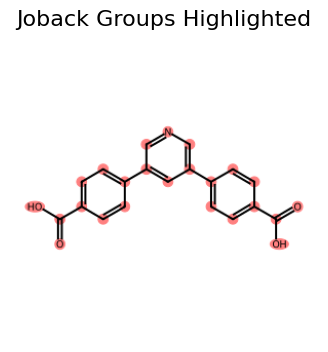


--- Joback Group Contributions ---
COOH         :  2  ->    75.08 J/mol.K
ring_n       :  1  ->     8.06 J/mol.K
ring_cH      : 11  ->   107.70 J/mol.K
ring_c       :  6  ->    38.53 J/mol.K

Total Cp_Joback = 229.37 J/mol.K


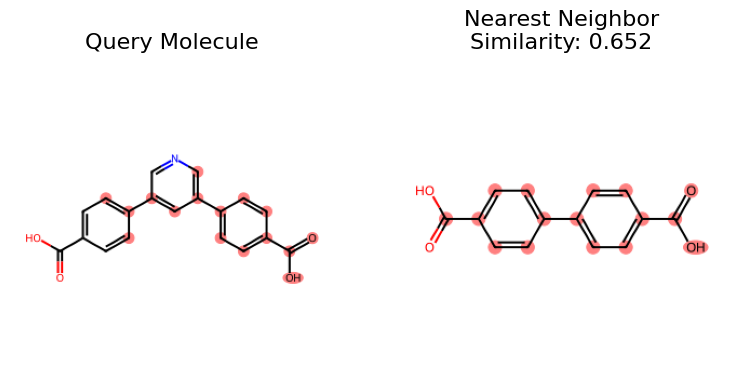


=== MORGAN FINGERPRINT QUERY ===
ON bits: [1, 7, 39, 67, 81, 100, 105, 106, 107, 114, 122, 125, 128, 133, 136, 138, 142, 161, 172, 200, 214, 221, 255]
Number of ON bits: 23
Using bit 7 for fragment visualization.

Visualisasi fragmen untuk bit 7 (QUERY MOLECULE)


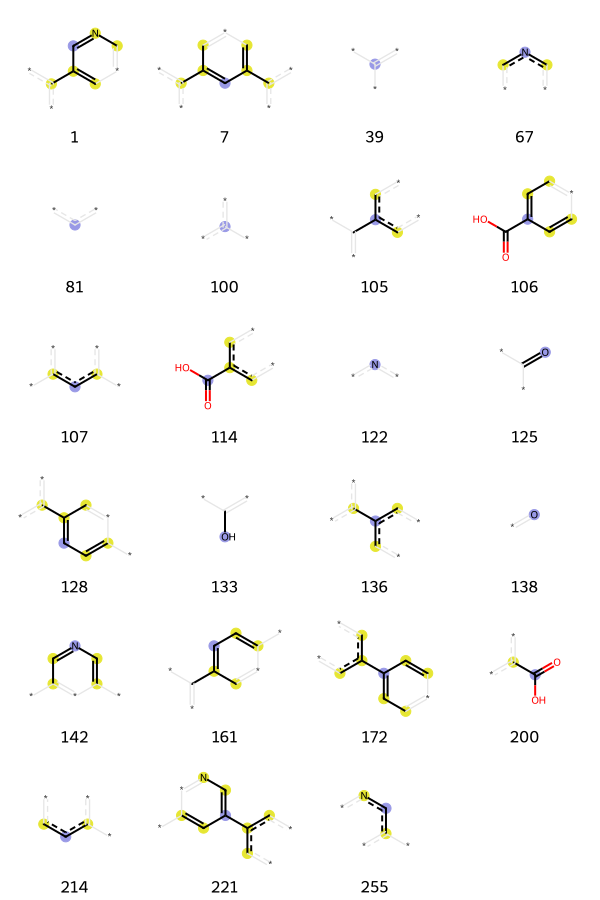


Fragmen pada molekul query yang mengaktifkan bit tersebut:


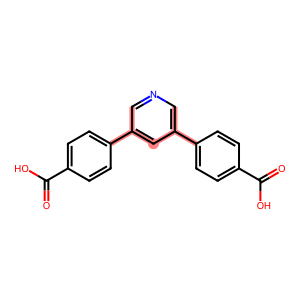

=== NEAREST NEIGHBOR INFO ===
Query SMILES        : C(=O)(O)C1=CC=C(C=C1)C=1C=NC=C(C1)C1=CC=C(C=C1)C(=O)O
Nearest neighbor   : O=C(O)c1ccc(-c2ccc(C(=O)O)cc2)cc1
Tanimoto similarity: 0.652
MolecularMass      : 319.32
ZPE (from NN)      : 560986.000
Entropy (from GNN) : 506.413

--- Cp Components ---
Temperature        : 85.00 °C  (358.15 K)
Cp_Joback source   : direct Joback from query at 358.15 K
Cp_Joback(query)  : 308.37 J/mol.K
Delta Cp (ML)     : 56.10 J/mol.K
Cp final          : 364.47 J/mol.K

Atom contribution scores for Entropy prediction:
Idx | Atom | Importance (0-1)
-----------------------------------
  0 |  C   | 0.9236
  1 |  O   | 0.6618
  2 |  O   | 0.6618
  3 |  C   | 0.9974
  4 |  C   | 0.8545
  5 |  C   | 0.8626
  6 |  C   | 0.9999
  7 |  C   | 0.8626
  8 |  C   | 0.8545
  9 |  C   | 1.0000
 10 |  C   | 0.9036
 11 |  N   | 0.9106
 12 |  C   | 0.9036
 13 |  C   | 1.0000
 14 |  C   | 0.8558
 15 |  C   | 0.9999
 16 |  C   | 0.8626
 17 |  C   | 0.8545
 18 |  C   | 0.9974


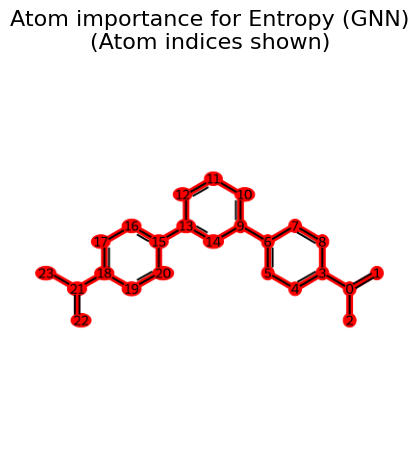

Processing SMILES: C(=O)(O)C1=CC=C(C=C1)C=1C(=NC(=C(N1)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C(=O)O)C=C1
Temperature      : 85.00 °C


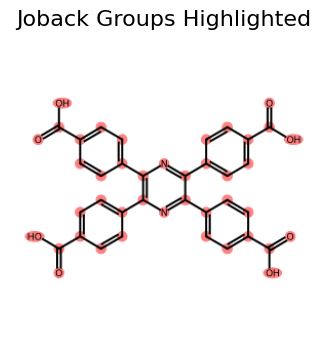


--- Joback Group Contributions ---
COOH         :  4  ->   150.16 J/mol.K
ring_n       :  2  ->    16.12 J/mol.K
ring_cH      : 16  ->   156.65 J/mol.K
ring_c       : 12  ->    77.05 J/mol.K

Total Cp_Joback = 399.99 J/mol.K


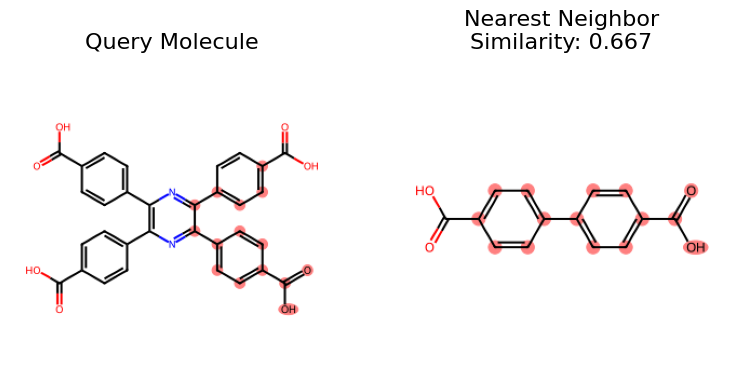


=== MORGAN FINGERPRINT QUERY ===
ON bits: [39, 63, 67, 81, 100, 105, 106, 114, 122, 125, 128, 133, 136, 138, 161, 200, 208, 210, 214, 215]
Number of ON bits: 20
Bit 7 not active, using first ON bit: 39

Visualisasi fragmen untuk bit 39 (QUERY MOLECULE)


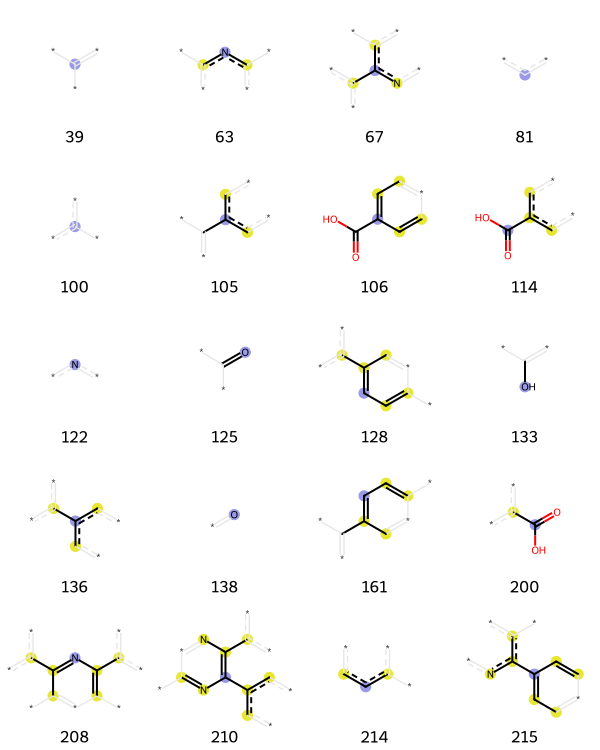


Fragmen pada molekul query yang mengaktifkan bit tersebut:


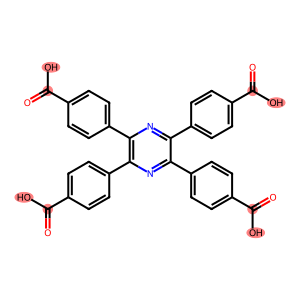

=== NEAREST NEIGHBOR INFO ===
Query SMILES        : C(=O)(O)C1=CC=C(C=C1)C=1C(=NC(=C(N1)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C(=O)O)C=C1
Nearest neighbor   : O=C(O)c1ccc(-c2ccc(C(=O)O)cc2)cc1
Tanimoto similarity: 0.667
MolecularMass      : 560.52
ZPE (from NN)      : 560986.000
Entropy (from GNN) : 502.645

--- Cp Components ---
Temperature        : 85.00 °C  (358.15 K)
Cp_Joback source   : direct Joback from query at 358.15 K
Cp_Joback(query)  : 532.33 J/mol.K
Delta Cp (ML)     : 53.84 J/mol.K
Cp final          : 586.17 J/mol.K

Atom contribution scores for Entropy prediction:
Idx | Atom | Importance (0-1)
-----------------------------------
  0 |  C   | 0.9260
  1 |  O   | 0.6635
  2 |  O   | 0.6635
  3 |  C   | 1.0000
  4 |  C   | 0.8567
  5 |  C   | 0.8648
  6 |  C   | 0.9934
  7 |  C   | 0.8648
  8 |  C   | 0.8567
  9 |  C   | 0.9895
 10 |  C   | 0.9895
 11 |  N   | 0.8499
 12 |  C   | 0.9895
 13 |  C   | 0.9895
 14 |  N   | 0.8499
 15 |  C   | 0.9934
 16 |  C   | 0.864

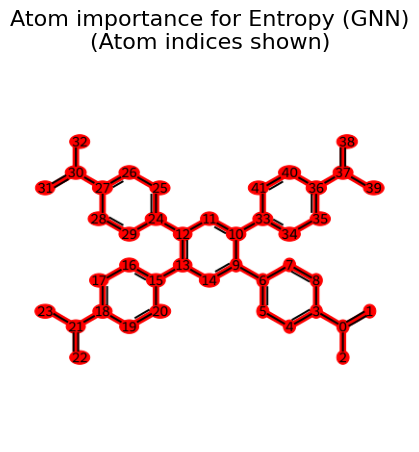

Processing SMILES: S1C(=CC=C1C(=O)O)C(=O)O
Temperature      : 120.00 °C


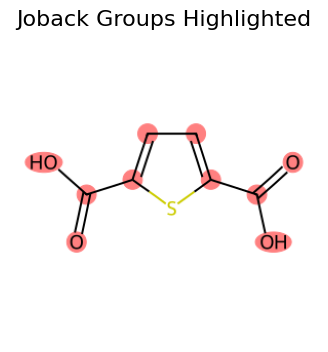


--- Joback Group Contributions ---
COOH         :  2  ->    75.08 J/mol.K
ring_cH      :  2  ->    19.58 J/mol.K
ring_c       :  2  ->    12.84 J/mol.K

Total Cp_Joback = 107.51 J/mol.K


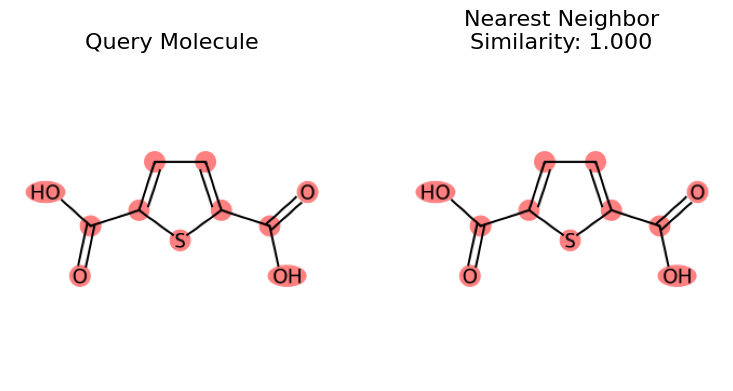


=== MORGAN FINGERPRINT QUERY ===
ON bits: [39, 81, 90, 100, 111, 125, 133, 138, 162, 163, 173, 200, 214]
Number of ON bits: 13
Bit 7 not active, using first ON bit: 39

Visualisasi fragmen untuk bit 39 (QUERY MOLECULE)


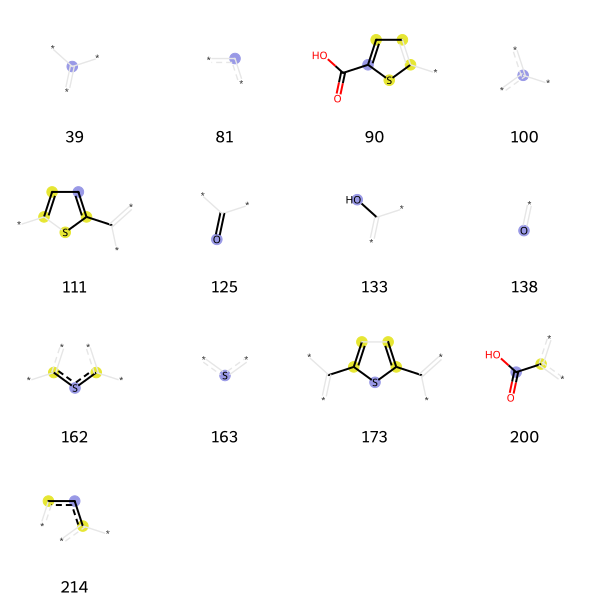


Fragmen pada molekul query yang mengaktifkan bit tersebut:


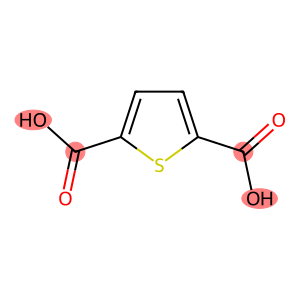

=== NEAREST NEIGHBOR INFO ===
Query SMILES        : S1C(=CC=C1C(=O)O)C(=O)O
Nearest neighbor   : O=C(O)c1ccc(C(=O)O)s1
Tanimoto similarity: 1.000
MolecularMass      : 172.16
ZPE (from NN)      : 258070.400
Entropy (from GNN) : 409.437

--- Cp Components ---
Temperature        : 120.00 °C  (393.15 K)
Cp_Joback source   : direct Joback from query at 393.15 K
Cp_Joback(query)  : 144.24 J/mol.K
Delta Cp (ML)     : 37.76 J/mol.K
Cp final          : 181.99 J/mol.K

Atom contribution scores for Entropy prediction:
Idx | Atom | Importance (0-1)
-----------------------------------
  0 |  S   | 0.8559
  1 |  C   | 1.0000
  2 |  C   | 0.8510
  3 |  C   | 0.8510
  4 |  C   | 1.0000
  5 |  C   | 0.9208
  6 |  O   | 0.6602
  7 |  O   | 0.6602
  8 |  C   | 0.9208
  9 |  O   | 0.6602
 10 |  O   | 0.6602


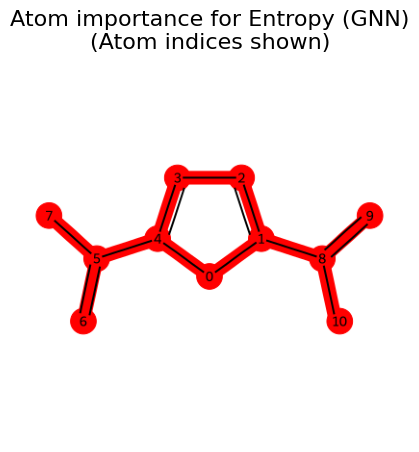

Processing SMILES: C(=O)O
Temperature      : 70.00 °C


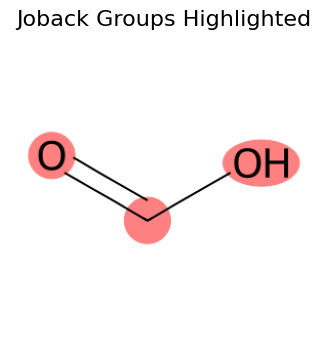


--- Joback Group Contributions ---
COOH         :  1  ->    37.54 J/mol.K

Total Cp_Joback = 37.54 J/mol.K


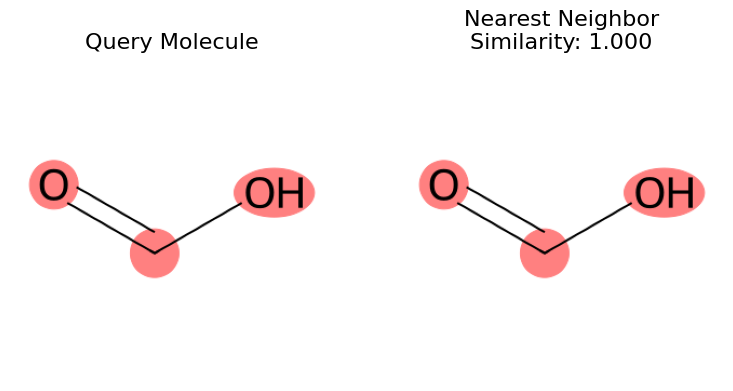


=== MORGAN FINGERPRINT QUERY ===
ON bits: [39, 56, 123, 138, 182, 236]
Number of ON bits: 6
Bit 7 not active, using first ON bit: 39

Visualisasi fragmen untuk bit 39 (QUERY MOLECULE)


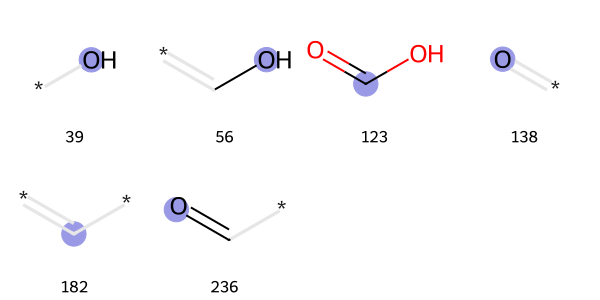


Fragmen pada molekul query yang mengaktifkan bit tersebut:


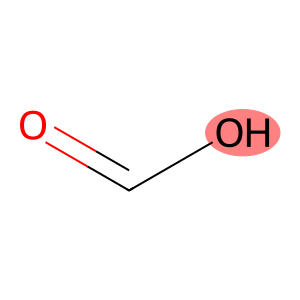

=== NEAREST NEIGHBOR INFO ===
Query SMILES        : C(=O)O
Nearest neighbor   : O=CO
Tanimoto similarity: 1.000
MolecularMass      : 46.03
ZPE (from NN)      : 89860.200
Entropy (from GNN) : 236.131

--- Cp Components ---
Temperature        : 70.00 °C  (343.15 K)
Cp_Joback source   : direct Joback from query at 343.15 K
Cp_Joback(query)  : 41.86 J/mol.K
Delta Cp (ML)     : -0.57 J/mol.K
Cp final          : 41.29 J/mol.K

Atom contribution scores for Entropy prediction:
Idx | Atom | Importance (0-1)
-----------------------------------
  0 |  C   | 1.0000
  1 |  O   | 0.7739
  2 |  O   | 0.7739


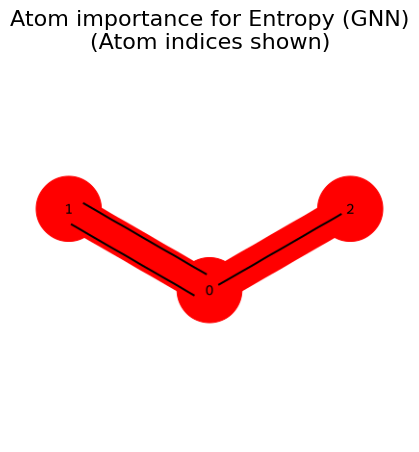

Processing SMILES: N=1N=C(NC1C=1C=C(C=C(C1)C(=O)O)C(=O)O)C=1C=C(C=C(C1)C(=O)O)C(=O)O
Temperature      : 70.00 °C


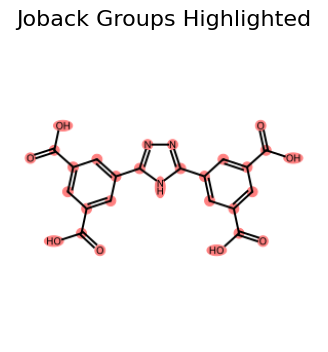


--- Joback Group Contributions ---
COOH         :  4  ->   150.16 J/mol.K
ring_nH      :  1  ->    11.43 J/mol.K
ring_n       :  2  ->    16.12 J/mol.K
ring_cH      :  6  ->    58.74 J/mol.K
ring_c       :  8  ->    51.37 J/mol.K

Total Cp_Joback = 287.83 J/mol.K


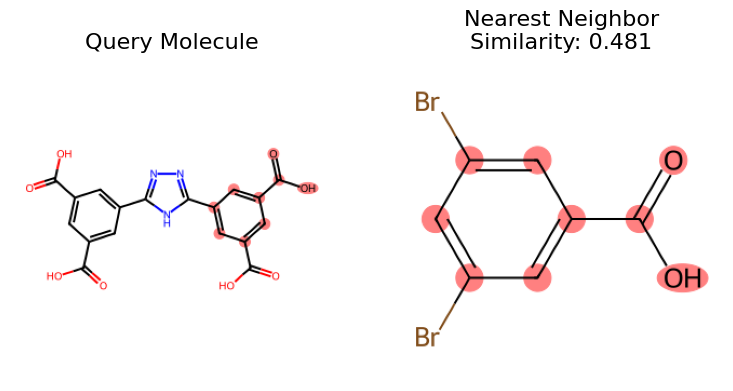


=== MORGAN FINGERPRINT QUERY ===
ON bits: [3, 31, 38, 39, 73, 81, 90, 100, 105, 107, 114, 122, 125, 133, 135, 136, 138, 140, 143, 195, 200, 209, 213]
Number of ON bits: 23
Bit 7 not active, using first ON bit: 3

Visualisasi fragmen untuk bit 3 (QUERY MOLECULE)


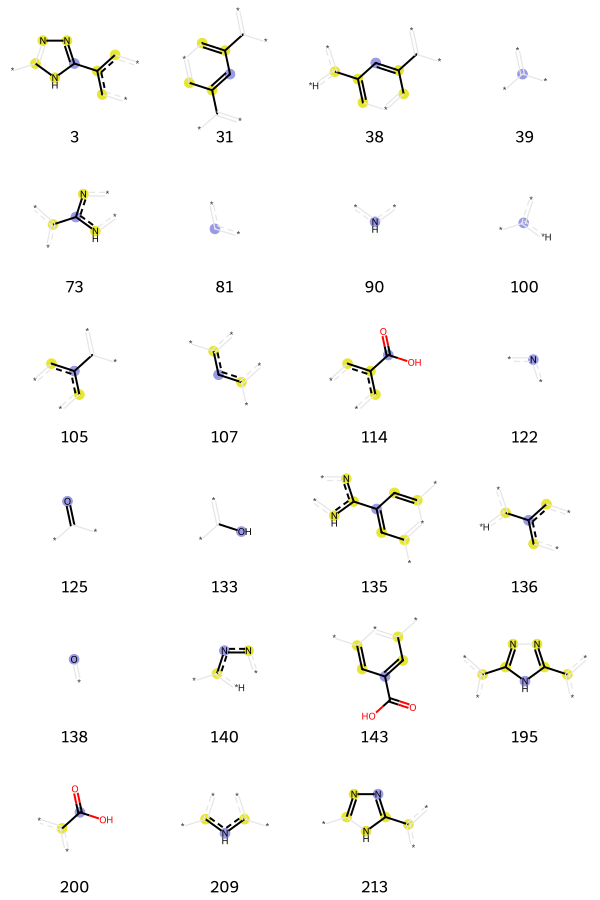


Fragmen pada molekul query yang mengaktifkan bit tersebut:


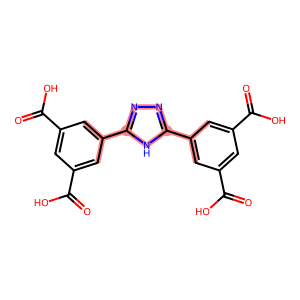

=== NEAREST NEIGHBOR INFO ===
Query SMILES        : N=1N=C(NC1C=1C=C(C=C(C1)C(=O)O)C(=O)O)C=1C=C(C=C(C1)C(=O)O)C(=O)O
Nearest neighbor   : O=C(O)c1cc(Br)cc(Br)c1
Tanimoto similarity: 0.481
MolecularMass      : 397.30
ZPE (from NN)      : 252662.100
Entropy (from GNN) : 426.420

--- Cp Components ---
Temperature        : 70.00 °C  (343.15 K)
Cp_Joback source   : direct Joback from query at 343.15 K
Cp_Joback(query)  : 350.67 J/mol.K
Delta Cp (ML)     : 37.02 J/mol.K
Cp final          : 387.69 J/mol.K

Atom contribution scores for Entropy prediction:
Idx | Atom | Importance (0-1)
-----------------------------------
  0 |  N   | 0.8798
  1 |  N   | 0.8798
  2 |  C   | 1.0000
  3 |  N   | 0.8591
  4 |  C   | 1.0000
  5 |  C   | 0.9658
  6 |  C   | 0.8382
  7 |  C   | 0.9635
  8 |  C   | 0.8301
  9 |  C   | 0.9635
 10 |  C   | 0.8382
 11 |  C   | 0.9135
 12 |  O   | 0.6545
 13 |  O   | 0.6545
 14 |  C   | 0.9135
 15 |  O   | 0.6545
 16 |  O   | 0.6545
 17 |  C   | 0.9658
 18 |  C   | 0.8382

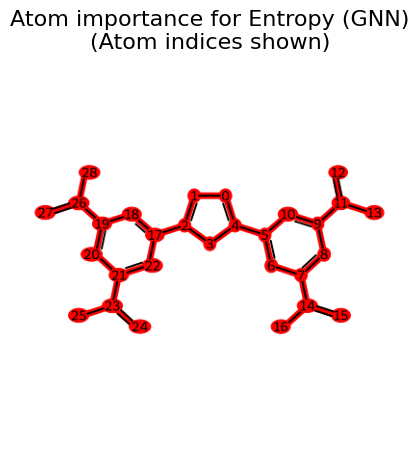

Processing SMILES: C(#CC=1C=C(C=C(C(=O)O)C1)C(=O)O)C=1C=C(C=C(C(=O)O)C1)C(=O)O
Temperature      : 65.00 °C


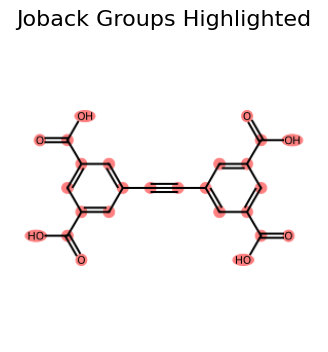


--- Joback Group Contributions ---
COOH         :  4  ->   150.16 J/mol.K
ring_cH      :  6  ->    58.74 J/mol.K
ring_c       :  6  ->    38.53 J/mol.K
C#C          :  1  ->     8.54 J/mol.K

Total Cp_Joback = 255.98 J/mol.K


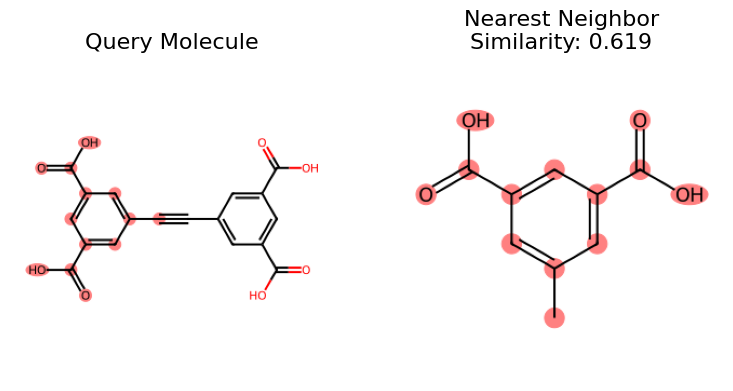


=== MORGAN FINGERPRINT QUERY ===
ON bits: [13, 31, 33, 39, 81, 100, 102, 105, 107, 114, 125, 133, 138, 143, 162, 174, 189, 200]
Number of ON bits: 18
Bit 7 not active, using first ON bit: 13

Visualisasi fragmen untuk bit 13 (QUERY MOLECULE)


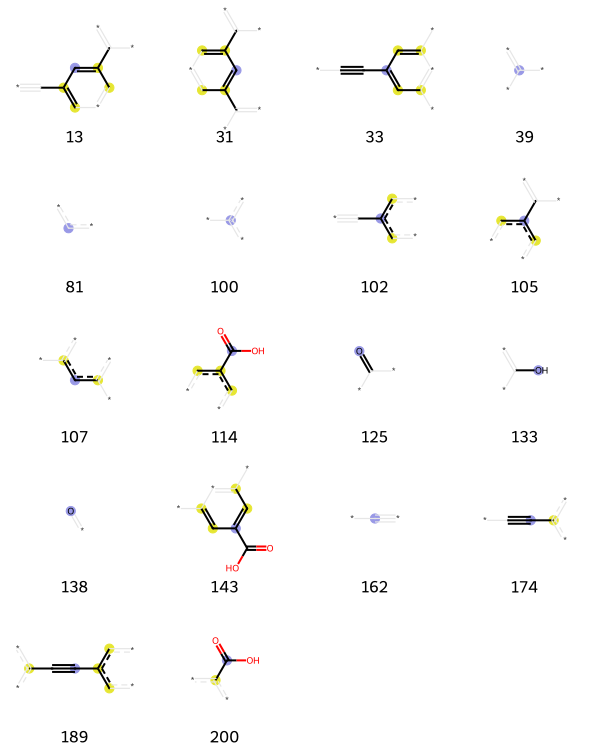


Fragmen pada molekul query yang mengaktifkan bit tersebut:


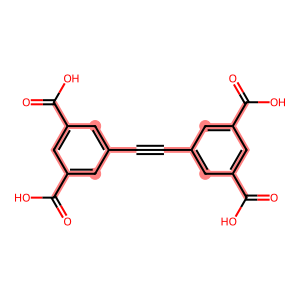

=== NEAREST NEIGHBOR INFO ===
Query SMILES        : C(#CC=1C=C(C=C(C(=O)O)C1)C(=O)O)C=1C=C(C=C(C(=O)O)C1)C(=O)O
Nearest neighbor   : Cc1cc(C(=O)O)cc(C(=O)O)c1
Tanimoto similarity: 0.619
MolecularMass      : 354.27
ZPE (from NN)      : 418643.800
Entropy (from GNN) : 448.518

--- Cp Components ---
Temperature        : 65.00 °C  (338.15 K)
Cp_Joback source   : direct Joback from query at 338.15 K
Cp_Joback(query)  : 304.34 J/mol.K
Delta Cp (ML)     : 41.25 J/mol.K
Cp final          : 345.59 J/mol.K

Atom contribution scores for Entropy prediction:
Idx | Atom | Importance (0-1)
-----------------------------------
  0 |  C   | 0.7036
  1 |  C   | 0.7036
  2 |  C   | 0.8881
  3 |  C   | 0.8327
  4 |  C   | 1.0000
  5 |  C   | 0.8612
  6 |  C   | 1.0000
  7 |  C   | 0.9483
  8 |  O   | 0.6798
  9 |  O   | 0.6798
 10 |  C   | 0.8327
 11 |  C   | 0.9483
 12 |  O   | 0.6798
 13 |  O   | 0.6798
 14 |  C   | 0.8881
 15 |  C   | 0.8327
 16 |  C   | 1.0000
 17 |  C   | 0.8612
 18 |  C   | 1.0000
 1

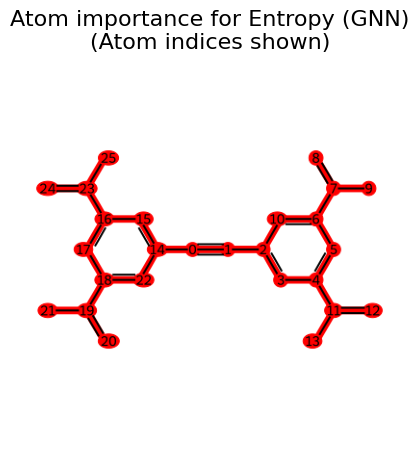

In [ ]:
smiles_list = [
    "C(=O)(O)C1=CC=C(C=C1)C=1C=NC=C(C1)C1=CC=C(C=C1)C(=O)O",
    "C(=O)(O)C1=CC=C(C=C1)C=1C(=NC(=C(N1)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C(=O)O)C=C1",
    "S1C(=CC=C1C(=O)O)C(=O)O",
    "C(=O)O",
    "N=1N=C(NC1C=1C=C(C=C(C1)C(=O)O)C(=O)O)C=1C=C(C=C(C1)C(=O)O)C(=O)O",
    "C(#CC=1C=C(C=C(C(=O)O)C1)C(=O)O)C=1C=C(C=C(C(=O)O)C1)C(=O)O"
]

T_list_C = [
    85.0,
    85.0,
    120.0,
    70.0,
    70.0,
    65.0,
]

for smi, T_C in zip(smiles_list, T_list_C):
    print("="*80)
    print(f"Processing SMILES: {smi}")
    print(f"Temperature      : {T_C:.2f} °C")

    # Visualisasi NN
    try:
        visualize_nn_2d(
            smi,
            T_C,
            df,
            X_phys_poly,
            cp_model,
            scaler_X,
            gnn,
            device=DEVICE
        )
    except Exception as e:
        print(f"SMILES: {smi} -> ERROR in visualize_nn_2d: {e}")

    # Atom importance
    try:
        atom_scores = visualize_atom_importance(
            smi,
            gnn,
            scaler_entropy,
            device=DEVICE
        )
    except Exception as e:
        print(f"SMILES: {smi} -> ERROR in visualize_atom_importance: {e}")
